# Librerías

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [2]:
# ===============================
# Core
# ===============================
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

# ===============================
# Proyecto / utilidades propias
# ===============================
from spectralcrop import PathManager

# ===============================
# Geoespacial
# ===============================
import rasterio

# ===============================
# Visualización
# ===============================
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ===============================
# Machine Learning clásico
# ===============================
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import joblib

# ===============================
# Deep Learning (PyTorch)
# ===============================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# ===============================
# Optimización de hiperparámetros
# ===============================
import optuna

import mlflow
import dagshub

c:\Users\mario\Documentos\personal_projects\thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

dagshub.init(repo_owner='johnma96', repo_name='thesis', mlflow=True)

Accessing as johnma96

Initialized MLflow to track repo "johnma96/thesis"

Repository johnma96/thesis initialized!

In [4]:
interim_data = PathManager().get_abs_path_folder("interim")
zarr_path = interim_data + "masked_reflectance.zarr"

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

def nearest_band_index(wavelengths_nm, target_nm):
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    idx = int(np.abs(wavelengths_nm - target_nm).argmin())
    return idx, float(wavelengths_nm[idx])

# Cargar información

## Cubo de datos

In [5]:
ds = xr.open_zarr(zarr_path, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]
nodata_mask = ds["mask_nodata"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")



<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


C:\Users\mario\AppData\Local\Temp\ipykernel_7932\4113903066.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_path, chunks={"band": 64, "y": 512, "x": 512})


In [6]:
# Contar NaNs por píxel en reflectancia
nan_counts = refl_byx.isnull().sum(dim=["y", "x"])  # suma sobre y y x

In [7]:
print(nan_counts.values.max(), nan_counts.values.min())

6432671 6411637


In [8]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = refl_byx.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")


Píxeles con ≥1 NaN: 6484992 (51.54%)


In [9]:
veg_mask

<xarray.DataArray 'veg_mask' (y: 3660, x: 3438)> Size: 13MB
dask.array<astype, shape=(3660, 3438), dtype=bool, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    0:                  no-veg
    1:                  veg
    dimension_names:    ['y', 'x']
    _ARRAY_DIMENSIONS:  ['y', 'x']

In [10]:
# Pixeles válidos - vegetación
(veg_mask == 1).values.sum().sum() 

np.int64(6127993)

In [11]:
# Pixeles inválidos - vegetación
(veg_mask == 1).shape[0]*(veg_mask == 1).values.shape[1] - (veg_mask == 1).values.sum().sum()

np.int64(6455087)

In [12]:
nodata_mask

<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  NoData mask (0=valid, 1=NoData)
    source:     c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\int...

In [13]:
# Pixeles válidos - no datos
(nodata_mask == 0).values.sum().sum()

np.int64(6098088)

In [14]:
# Pixeles inválidos - no datos
(nodata_mask == 0).shape[0]*(nodata_mask == 0).values.shape[1] - (nodata_mask == 0).values.sum().sum()

np.int64(6484992)

In [15]:
# -----------------------------
# Máscaras validadas para datos
# -----------------------------

valid_mask = (veg_mask & (nodata_mask == 0))
valid_mask.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [16]:
# Pixeles válidos
valid_mask.values.sum().sum()

np.int64(6055113)

In [17]:
# Pixeles inválidos
valid_mask.values.shape[0]*valid_mask.values.shape[1] - valid_mask.values.sum().sum()

np.int64(6527967)

Pixeles válidos: 6,055,113 (48.12%)


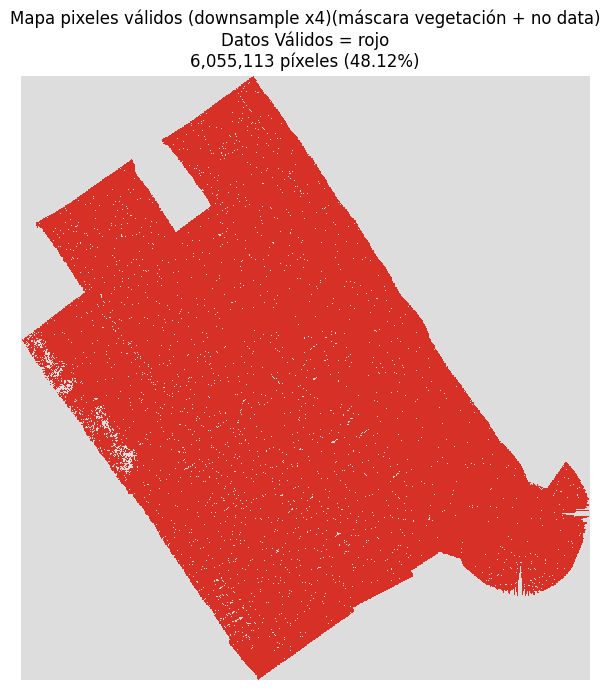

In [18]:
# --- Mapa visual de píxeles NoData (y superposición opcional de veg_mask) ---


# 2) Estadísticos rápidos
total_px = valid_mask.sizes["y"] * valid_mask.sizes["x"]
nodata_px = int(valid_mask.sum().compute())
nodata_pct = 100.0 * nodata_px / total_px
print(f"Pixeles válidos: {nodata_px:,} ({nodata_pct:.2f}%)")

# 3) Preparar una versión reducida para visualización rápida (downsample)
stride = 4
nodata_vis = valid_mask.isel(y=slice(None, None, stride),
                               x=slice(None, None, stride))

# 4) Visualización binaria clara (NoData=1 en rojo, Data=0 en gris claro)
cmap_bin = ListedColormap(["#dddddd", "#d73027"])  # data=gris, NoData=rojo

plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap=cmap_bin, interpolation="nearest")
plt.title(f"Mapa pixeles válidos (downsample x{stride})(máscara vegetación + no data)\nDatos Válidos = rojo\n{nodata_px:,} píxeles ({nodata_pct:.2f}%)")
plt.axis("off")
plt.tight_layout()
# plt.savefig(FIGURES_FOLDER + "/nodata_map_binary.png", dpi=150)
plt.show()

## Etiquetas

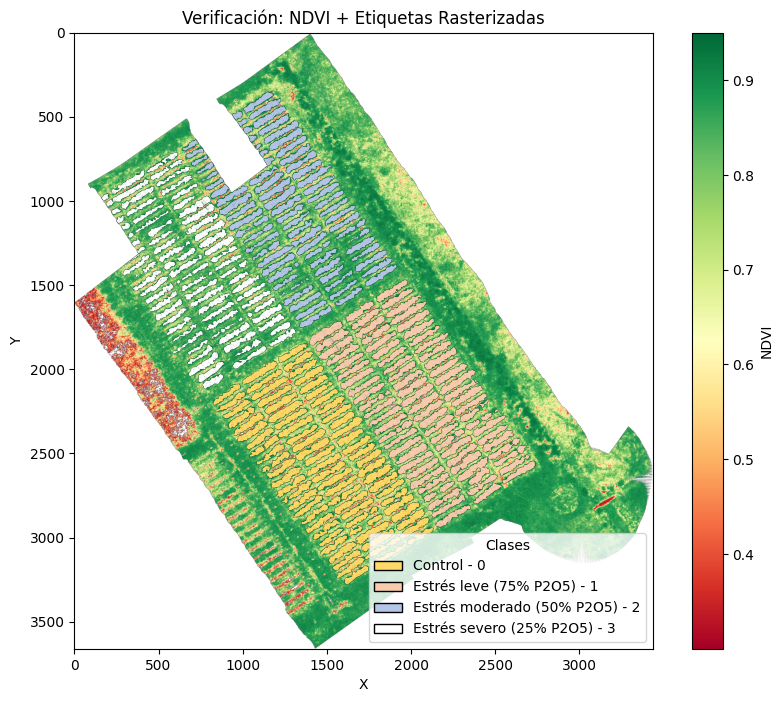

In [19]:
# --- Rutas ---
labels_tiff_path = Path(PathManager().get_abs_path_file("labels_multiclass.tif"))

ndvi = ds["NDVI"].compute()  # Cargar NDVI en memoria para graficar

# --- Obtener transform y CRS ---
crs = ndvi.rio.crs
transform = ndvi.rio.transform()
height, width = ndvi.shape

# Calcular extent para imshow
x_min = transform.c
x_max = transform.c + width * transform.a
y_max = transform.f
y_min = transform.f + height * transform.e  # e es negativo
extent = (x_min, x_max, y_min, y_max)

# --- Abrir GeoTIFF de etiquetas ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)

# --- Graficar overlay ---
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(ndvi, cmap="RdYlGn", extent=extent, origin="upper")


# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estrés leve (75% P2O5) - 1",
    2: "Estrés moderado (50% P2O5) - 2",
    3: "Estrés severo (25% P2O5) - 3",
}
colors = ["#FFD966", "#F8CBAD", "#B4C6E7", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

masked_labels = np.ma.masked_where(labels == 255, labels)
ax.imshow(masked_labels, cmap=cmap_labels, alpha=1, extent=extent, origin="upper")

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación: NDVI + Etiquetas Rasterizadas")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.colorbar(img, ax=ax, label="NDVI")
plt.show()

In [20]:
# --- Abrir etiquetas como array ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)  # numpy array (y, x)

# Convertir a binario: 0 = control, resto (1,2,3) = enfermo
labels_bin = np.where(labels == 0, 0, 
                      np.where(
                          np.isin(labels, [1, 2, 3]), 1, np.nan
                        )
                    )

# Aplicar máscara veg-valid
# labels_bin = np.where(valid_mask, labels_bin, np.nan)

In [21]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [22]:
np.isnan(labels_bin).sum().sum()

np.int64(10834441)

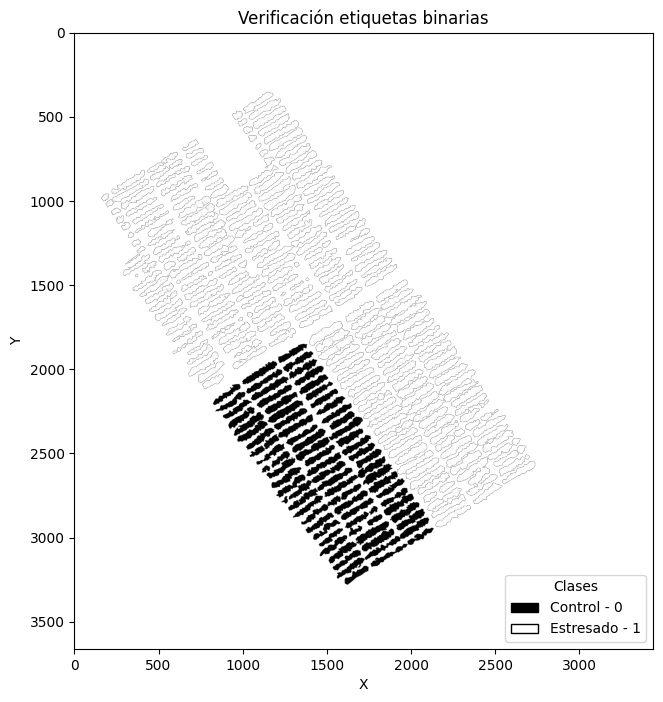

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

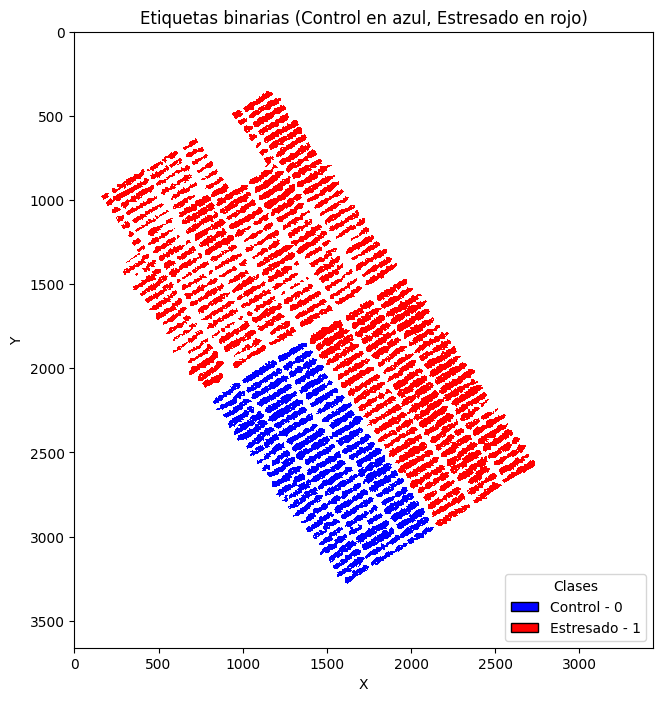

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()


In [25]:
np.isnan(labels_bin).sum()

np.int64(10834441)

In [26]:
labels_bin.shape[0] * labels_bin.shape[1] - np.isnan(labels_bin).sum()

np.int64(1748639)

# 1. Preparación de datos

## 1.1 Preparar matriz de características X

In [27]:
# -----------------------------
# 5. Extraer índices espectrales y bandas clave
# -----------------------------
# Índices ya calculados en Zarr: NDVI, NDRE, CIgreen, PRI, PSRI
indices = ds[["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]]

# Selección de bandas clave por correlación - ver notebook 201-jmmz-select-bands-by-correlation.ipynb
path_selected_bands = PathManager().get_abs_path_file("bands_selected_by_segment.csv")
selected_bands_df = pd.read_csv(path_selected_bands)
selected_bands = selected_bands_df['band_index'].tolist()

reflectance_selected = ds["reflectance"].isel(band=selected_bands)
reflectance_selected

<xarray.DataArray 'reflectance' (band: 58, y: 3660, x: 3438)> Size: 3GB
dask.array<getitem, shape=(58, 3660, 3438), dtype=float32, chunksize=(58, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 232B 1 13 31 41 48 55 67 ... 348 350 352 355 362 374
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']

In [28]:
indices_da = indices.to_array(dim="band")
indices_da

<xarray.DataArray (band: 5, y: 3660, x: 3438)> Size: 252MB
dask.array<stack, shape=(5, 3660, 3438), dtype=float32, chunksize=(1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 40B 'NDVI' 'NDRE' 'CIgreen' 'PRI' 'PSRI'
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [29]:
nan_counts = indices_da.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)

[6527967 6528031 7596119 7071551 6575062]


In [30]:
# "NDVI", "NDRE", "CIgreen", "PRI", "PSRI"
(~indices_da.isnull()).sum(dim=["y", "x"]).values

# -> CIgreen tiene más NaN que el resto

array([6055113, 6055049, 4986961, 5511529, 6008018])

In [31]:
# -----------------------------
# 6. Construir DataFrame para ML
# -----------------------------
# Aplanar datos válidos
features_stack = xr.concat([indices_da, reflectance_selected], dim="band")
features_stack = features_stack.transpose("y", "x", "band")
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<transpose, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [32]:
nan_counts = features_stack.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)


[6527967 6528031 7596119 7071551 6575062 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411795 6411976 6411921 6412079 6412215 6411748
 6411746 6411768 6411798 6411680 6411663 6411652 6411664 6411678 6411680
 6411708 6411701 6411753 6411742 6411805 6412085 6411960 6412297 6411998]


In [33]:

print("Size features:", features_stack.sizes)
print("Size labels:", labels_bin.shape)


Size features: Frozen({'y': 3660, 'x': 3438, 'band': 63})
Size labels: (3660, 3438)


In [34]:
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<transpose, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [35]:
labels_bin.shape[0]*labels_bin.shape[1]

12583080

In [36]:
# Máscara para extraer solo píxeles válidos
valid_pixels = valid_mask #& ~np.isnan(labels_bin)
valid_pixels.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [37]:
# Extraer valores
X = features_stack.where(valid_pixels)#.values.reshape(-1, features_stack.shape[-1])
X

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<where, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [38]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = ds['reflectance'].isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6484992 (51.54%)


In [39]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = reflectance_selected.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6416232 (50.99%)


In [40]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = indices_da.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


In [41]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = features_stack.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")
print(f"Píxeles válidos: {features_stack.shape[0]*features_stack.shape[1] - count_nan_pixels}")

Píxeles con ≥1 NaN: 7596119 (60.37%)
Píxeles válidos: 4986961


In [42]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = X.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


Voy a enmascarar los labels para que coincidan con X

In [43]:
X.isnull().any(dim="band").values

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(3660, 3438))

In [44]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [45]:

# Enmascarar: donde mask_nan_pixels == True -> NaN
labels_bin_masked = np.where(X.isnull().any(dim="band").values, np.nan, labels_bin)
labels_bin_masked

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

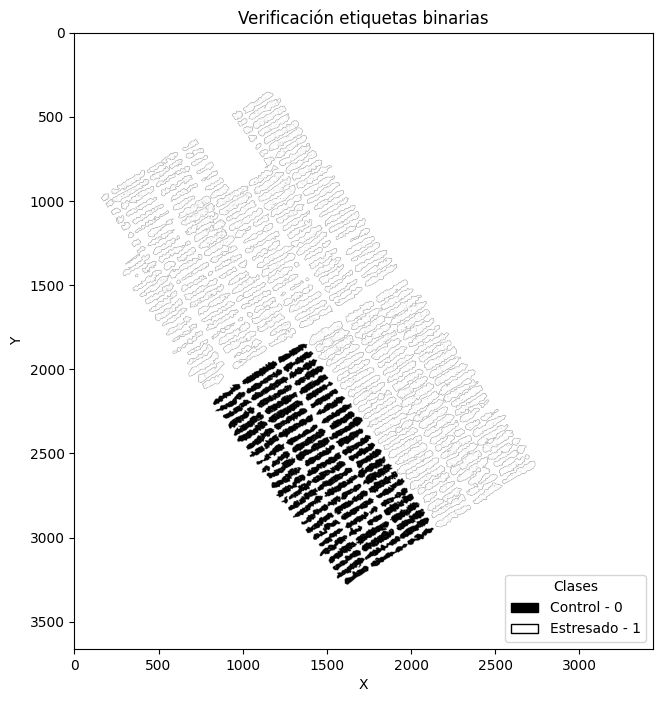

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin_masked, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()


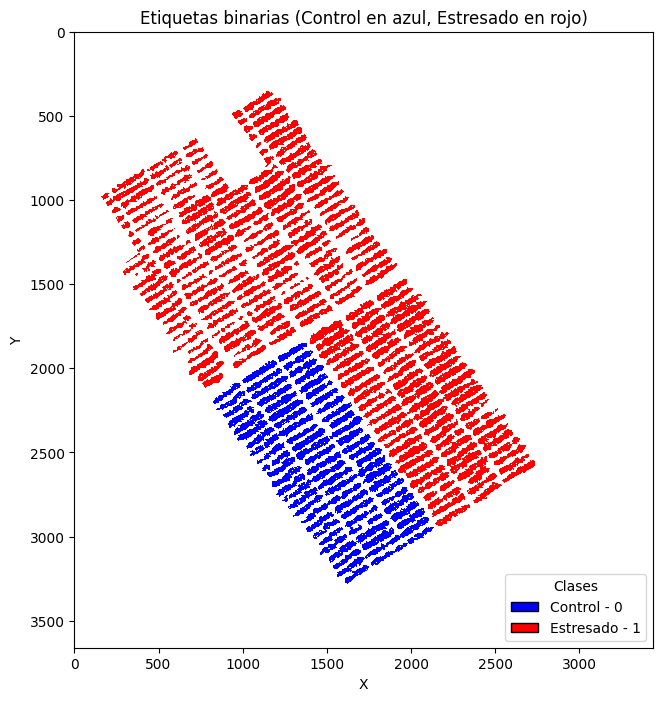

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin_masked, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

In [48]:
np.isnan(labels_bin_masked).sum()

np.int64(10868816)

In [49]:
labels_bin_masked.shape[0] * labels_bin_masked.shape[1] - np.isnan(labels_bin_masked).sum()

np.int64(1714264)

Hay 1714264 labels que tienen todos los features válidos y  además tienen etiqueta válida (0 o 1).

In [50]:
X2 = X.values.reshape(-1, features_stack.shape[-1])
X2

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(12583080, 63), dtype=float32)

In [51]:
labels_bin.reshape(-1)

array([nan, nan, nan, ..., nan, nan, nan], shape=(12583080,))

In [52]:
## Cargar el split espacial del notebook 302-jmmz-spatial-split.ipynb
OUT_SPLIT_TIFF = PathManager().get_abs_path_folder('processed') + "/splits/by_plot_split_id_binary.tif"

with rasterio.open(OUT_SPLIT_TIFF) as src:
    split_id = src.read(1)


split_id

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3660, 3438), dtype=uint8)

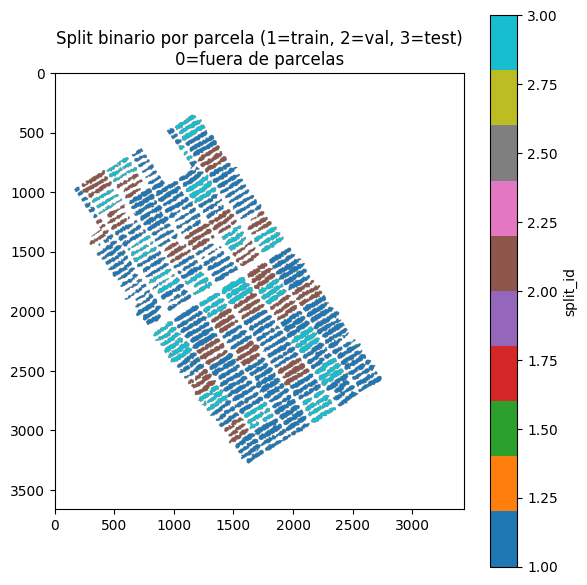

Conteo de píxeles por split: {np.uint8(1): np.int64(1038541), np.uint8(2): np.int64(353211), np.uint8(3): np.int64(372966)}


In [53]:
plt.figure(figsize=(6,6))
plt.imshow(np.where(split_id==0, np.nan, split_id), cmap="tab10", vmin=1, vmax=3)
plt.title("Split binario por parcela (1=train, 2=val, 3=test)\n0=fuera de parcelas")
plt.colorbar(label="split_id")
plt.tight_layout()
plt.show()

# Conteo de píxeles por split dentro de parcelas
vals, counts = np.unique(split_id[split_id>0], return_counts=True)
print("Conteo de píxeles por split:", dict(zip(vals, counts)))

In [54]:
np.unique(np.where(split_id==0, np.nan, split_id).reshape(-1, 1))

array([ 1.,  2.,  3., nan])

In [55]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [ ]:
data = np.concatenate([X2, 
                       labels_bin.reshape(-1, 1),
                     #   split_id.reshape(-1, 1),
                       np.where(split_id==0, np.nan, split_id).reshape(-1, 1),
                       ], axis=1)
data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(12583080, 65))

In [56]:
X2[0]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
      dtype=float32)

In [57]:
pd.DataFrame(data).head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
pd.DataFrame(X2).shape[0] - pd.DataFrame(X2).isna().sum()

# La columna que corresponde a CIgreen tiene más NaN que el resto

0     6055113
1     6055049
2     4986961
3     5511529
4     6008018
       ...   
58    6055113
59    6055113
60    6055113
61    6055113
62    6055113
Length: 63, dtype: int64

In [59]:
pd.DataFrame(X2).dropna(axis=0, how='any')

# CIgreen tiene más NaN que el resto, por tanto controla el shape final de X

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
18591,0.876371,0.388399,6.273077,-0.033175,0.004831,6.700000e-07,4.700000e-07,6.000000e-07,0.000002,0.000003,...,1.030000e-06,9.200000e-07,6.900000e-07,5.600000e-07,6.600000e-07,9.400000e-07,8.200000e-07,8.700000e-07,8.900000e-07,2.300000e-06
18592,0.880613,0.424105,7.569306,-0.042424,0.003342,5.900000e-07,4.100000e-07,4.900000e-07,0.000002,0.000002,...,7.300000e-07,6.800000e-07,8.400000e-07,8.000001e-07,7.700000e-07,7.300000e-07,4.200000e-07,4.700000e-07,8.700000e-07,3.520000e-06
22027,0.888262,0.451585,8.156757,-0.039216,0.002761,4.400000e-07,3.100000e-07,4.200000e-07,0.000001,0.000002,...,7.200000e-07,7.800000e-07,1.030000e-06,1.140000e-06,9.200000e-07,6.000000e-07,2.000000e-07,7.000000e-07,5.300000e-07,1.640000e-06
22028,0.882353,0.408375,6.766949,-0.036082,0.003781,5.900000e-07,3.700000e-07,5.200000e-07,0.000002,0.000002,...,6.300000e-07,6.600000e-07,9.300000e-07,1.000000e-06,9.600001e-07,9.200000e-07,5.800000e-07,8.100000e-07,5.800000e-07,1.180000e-06
22029,0.875403,0.411955,6.768888,-0.040650,0.003309,6.300000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,7.100000e-07,6.400000e-07,5.500000e-07,4.300000e-07,5.100000e-07,7.899999e-07,8.200000e-07,7.700000e-07,6.100000e-07,6.900000e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12567322,0.878031,0.306926,4.498925,-0.011704,-0.002907,8.600001e-07,9.200000e-07,1.160000e-06,0.000004,0.000005,...,9.400000e-07,1.080000e-06,1.200000e-06,1.260000e-06,1.560000e-06,1.480000e-06,1.170000e-06,1.280000e-06,8.900000e-07,9.800000e-07
12567323,0.881054,0.312920,4.516737,-0.011613,-0.000798,7.600000e-07,9.800000e-07,1.180000e-06,0.000004,0.000005,...,1.490000e-06,1.330000e-06,1.120000e-06,1.140000e-06,1.480000e-06,1.680000e-06,1.280000e-06,9.300000e-07,9.400000e-07,1.050000e-06
12567324,0.883433,0.338011,4.973154,-0.005571,-0.002783,8.400000e-07,9.800000e-07,1.180000e-06,0.000004,0.000004,...,1.690000e-06,1.360000e-06,1.280000e-06,1.160000e-06,1.310000e-06,1.100000e-06,8.900000e-07,9.600001e-07,1.260000e-06,1.240000e-06
12570760,0.879377,0.310884,4.751773,-0.004172,-0.000444,9.800000e-07,9.100000e-07,1.030000e-06,0.000004,0.000004,...,1.260000e-06,1.120000e-06,1.120000e-06,1.030000e-06,1.010000e-06,8.800000e-07,9.700000e-07,6.700000e-07,1.060000e-06,7.700000e-07


In [60]:
data_ = pd.DataFrame(data).dropna(axis=0, how='any')
data_.rename(columns={data_.columns[-2]: 'label'}, inplace=True)
data_.rename(columns={data_.columns[-1]: 'split'}, inplace=True)
data_ 

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,label,split
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,0.000002,0.000003,...,1.210000e-06,1.410000e-06,0.000001,0.000001,1.520000e-06,1.080000e-06,1.170000e-06,1.680000e-06,1.0,3.0
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,0.000003,0.000004,...,1.360000e-06,1.320000e-06,0.000001,0.000001,1.440000e-06,1.240000e-06,1.590000e-06,2.570000e-06,1.0,3.0
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,0.000002,0.000002,...,1.480000e-06,1.450000e-06,0.000001,0.000001,1.220000e-06,1.420000e-06,9.300000e-07,2.120000e-06,1.0,3.0
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,0.000003,0.000004,...,1.200000e-06,1.120000e-06,0.000001,0.000001,1.200000e-06,1.210000e-06,1.060000e-06,2.730000e-06,1.0,3.0
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,0.000003,0.000004,...,1.070000e-06,1.190000e-06,0.000001,0.000001,1.160000e-06,7.899999e-07,1.460000e-06,2.730000e-06,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.888521,0.366129,7.144231,-0.015290,0.001305,5.000000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,1.020000e-06,1.350000e-06,0.000002,0.000001,1.430000e-06,9.900000e-07,1.470000e-06,1.700000e-06,0.0,1.0
11264514,0.882600,0.398624,8.368794,-0.027027,0.003433,4.900000e-07,2.500000e-07,3.300000e-07,0.000001,0.000001,...,1.380000e-06,1.600000e-06,0.000002,0.000001,8.600001e-07,5.700000e-07,9.500000e-07,2.020000e-06,0.0,1.0
11267949,0.861718,0.342920,5.820225,0.004504,0.000000,7.899999e-07,7.200000e-07,8.400000e-07,0.000002,0.000003,...,1.160000e-06,9.700000e-07,0.000001,0.000001,9.500000e-07,1.200000e-06,1.250000e-06,1.180000e-06,0.0,1.0
11267950,0.844688,0.332175,5.390000,0.000000,-0.001731,7.800000e-07,9.500000e-07,1.080000e-06,0.000003,0.000003,...,1.310000e-06,8.100000e-07,0.000001,0.000001,1.030000e-06,1.530000e-06,5.200000e-07,8.300000e-07,0.0,1.0


In [61]:
resumen_df = data_.groupby(["label", "split"]).size().unstack(fill_value=0).rename(
    columns={1: 'train', 2: 'val', 3: 'test'}
)

resumen_df

split,train,val,test
label,,,
0.0,304220,93238,92596
1.0,704959,250037,269214


In [62]:
resumen_df.div(resumen_df.sum(axis=0), axis=1) * 100

split,train,val,test
label,,,
0.0,30.145296,27.161314,25.592438
1.0,69.854704,72.838686,74.407562


## 1.2 Separar X y y validados

In [63]:
X = data_.drop(columns=["label", "split"])
y = data_.loc[:, "label"]
split = data_.loc[:, "split"]

In [64]:
X

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,0.000002,0.000003,...,1.170000e-06,1.260000e-06,1.210000e-06,1.410000e-06,0.000001,0.000001,1.520000e-06,1.080000e-06,1.170000e-06,1.680000e-06
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,0.000003,0.000004,...,1.200000e-06,1.350000e-06,1.360000e-06,1.320000e-06,0.000001,0.000001,1.440000e-06,1.240000e-06,1.590000e-06,2.570000e-06
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,0.000002,0.000002,...,1.930000e-06,1.870000e-06,1.480000e-06,1.450000e-06,0.000001,0.000001,1.220000e-06,1.420000e-06,9.300000e-07,2.120000e-06
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,0.000003,0.000004,...,1.320000e-06,1.350000e-06,1.200000e-06,1.120000e-06,0.000001,0.000001,1.200000e-06,1.210000e-06,1.060000e-06,2.730000e-06
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,0.000003,0.000004,...,9.200000e-07,1.040000e-06,1.070000e-06,1.190000e-06,0.000001,0.000001,1.160000e-06,7.899999e-07,1.460000e-06,2.730000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.888521,0.366129,7.144231,-0.015290,0.001305,5.000000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,9.700000e-07,8.600001e-07,1.020000e-06,1.350000e-06,0.000002,0.000001,1.430000e-06,9.900000e-07,1.470000e-06,1.700000e-06
11264514,0.882600,0.398624,8.368794,-0.027027,0.003433,4.900000e-07,2.500000e-07,3.300000e-07,0.000001,0.000001,...,1.410000e-06,1.350000e-06,1.380000e-06,1.600000e-06,0.000002,0.000001,8.600001e-07,5.700000e-07,9.500000e-07,2.020000e-06
11267949,0.861718,0.342920,5.820225,0.004504,0.000000,7.899999e-07,7.200000e-07,8.400000e-07,0.000002,0.000003,...,1.250000e-06,1.270000e-06,1.160000e-06,9.700000e-07,0.000001,0.000001,9.500000e-07,1.200000e-06,1.250000e-06,1.180000e-06
11267950,0.844688,0.332175,5.390000,0.000000,-0.001731,7.800000e-07,9.500000e-07,1.080000e-06,0.000003,0.000003,...,1.190000e-06,1.480000e-06,1.310000e-06,8.100000e-07,0.000001,0.000001,1.030000e-06,1.530000e-06,5.200000e-07,8.300000e-07


In [65]:
y

1204447     1.0
1204448     1.0
1207884     1.0
1207885     1.0
1207886     1.0
           ... 
11264513    0.0
11264514    0.0
11267949    0.0
11267950    0.0
11267951    0.0
Name: label, Length: 1714264, dtype: float64

In [66]:
split

1204447     3.0
1204448     3.0
1207884     3.0
1207885     3.0
1207886     3.0
           ... 
11264513    1.0
11264514    1.0
11267949    1.0
11267950    1.0
11267951    1.0
Name: split, Length: 1714264, dtype: float64

In [67]:
print(f"Shape X: {X.shape}, Shape y: {y.shape}, shape split: {split.shape}, Clases: {np.unique(y)}, Split IDs: {np.unique(split)}")    

Shape X: (1714264, 63), Shape y: (1714264,), shape split: (1714264,), Clases: [0. 1.], Split IDs: [1. 2. 3.]


In [68]:
pd.Series(y).value_counts()

label
1.0    1224210
0.0     490054
Name: count, dtype: int64

## 1.3 Split de datos en train/test (Aplicando split espacial)

In [69]:
# División train, test, val usando los IDs espaciales cargados

X_train, X_val, X_test, y_train, y_val, y_test = (
    X[split == 1], X[split == 2], X[split == 3],
    y[split == 1], y[split == 2], y[split == 3],
)

In [70]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((1009179, 63), (1009179,), (361810, 63), (361810,), (343275, 63), (343275,))

In [71]:
resumen_df

split,train,val,test
label,,,
0.0,304220,93238,92596
1.0,704959,250037,269214


In [72]:
resumen_df.sum(axis=0)

split
train    1009179
val       343275
test      361810
dtype: int64

## 1.4 Scaler

### Create

In [73]:
# -----------------------------
# 3. Escalado robusto
# -----------------------------
# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

# # 2. Scaler
# base_joblib_path = "../models/checkpoints/"
# joblib.dump(scaler, base_joblib_path + "robust_scaler.pkl")

['../models/checkpoints/robust_scaler.pkl']

### Load

In [56]:

base_joblib_path = "../models/checkpoints/"
scaler = joblib.load(filename=base_joblib_path + "robust_scaler.pkl")

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [75]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
1592759,0.773256,0.334845,5.589552,-0.060345,0.027248,5.400000e-07,2.900000e-07,4.500000e-07,0.000001,0.000001,...,6.800000e-07,8.000001e-07,5.900000e-07,4.400000e-07,8.100000e-07,1.140000e-06,1.080000e-06,4.100000e-07,7.800000e-07,1.100000e-06
1592760,0.776410,0.338710,5.859504,-0.051643,0.022857,5.300000e-07,2.700000e-07,4.000000e-07,0.000001,0.000001,...,6.300000e-07,8.000001e-07,6.800000e-07,5.400000e-07,8.700000e-07,1.220000e-06,1.100000e-06,5.100000e-07,8.400000e-07,1.070000e-06
1592761,0.783300,0.327757,5.419118,-0.051724,0.024324,4.500000e-07,2.800000e-07,3.900000e-07,0.000001,0.000001,...,7.700000e-07,8.300000e-07,8.200000e-07,6.700000e-07,8.400000e-07,8.500000e-07,7.600000e-07,7.800000e-07,9.300000e-07,1.460000e-06
1596197,0.843421,0.296141,4.106227,-0.041096,0.010682,5.400000e-07,4.500000e-07,5.200000e-07,0.000002,0.000003,...,5.500000e-07,7.899999e-07,5.900000e-07,5.400000e-07,9.600001e-07,1.140000e-06,1.200000e-06,6.800000e-07,1.250000e-06,6.200000e-07
1596198,0.846564,0.296121,4.229007,-0.030023,0.007513,5.000000e-07,4.200000e-07,4.900000e-07,0.000002,0.000003,...,6.900000e-07,8.500000e-07,7.700000e-07,5.200000e-07,9.900000e-07,1.430000e-06,1.300000e-06,1.100000e-06,1.470000e-06,1.050000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.888521,0.366129,7.144231,-0.015290,0.001305,5.000000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,9.700000e-07,8.600001e-07,1.020000e-06,1.350000e-06,1.570000e-06,1.350000e-06,1.430000e-06,9.900000e-07,1.470000e-06,1.700000e-06
11264514,0.882600,0.398624,8.368794,-0.027027,0.003433,4.900000e-07,2.500000e-07,3.300000e-07,0.000001,0.000001,...,1.410000e-06,1.350000e-06,1.380000e-06,1.600000e-06,1.740000e-06,1.180000e-06,8.600001e-07,5.700000e-07,9.500000e-07,2.020000e-06
11267949,0.861718,0.342920,5.820225,0.004504,0.000000,7.899999e-07,7.200000e-07,8.400000e-07,0.000002,0.000003,...,1.250000e-06,1.270000e-06,1.160000e-06,9.700000e-07,1.090000e-06,1.200000e-06,9.500000e-07,1.200000e-06,1.250000e-06,1.180000e-06
11267950,0.844688,0.332175,5.390000,0.000000,-0.001731,7.800000e-07,9.500000e-07,1.080000e-06,0.000003,0.000003,...,1.190000e-06,1.480000e-06,1.310000e-06,8.100000e-07,1.100000e-06,1.140000e-06,1.030000e-06,1.530000e-06,5.200000e-07,8.300000e-07


In [76]:
X_train_scaled

array([[-5.2871528 , -0.64362406, -0.61960271, ..., -1.39999999,
        -0.83018882, -1.04395633],
       [-5.15468601, -0.58615462, -0.51652919, ..., -1.17777779,
        -0.71698126, -1.07692327],
       [-4.86535309, -0.74903358, -0.68467803, ..., -0.57777784,
        -0.54716986, -0.64835184],
       ...,
       [-1.57229569, -0.5235385 , -0.53152692, ...,  0.35555557,
         0.05660383, -0.95604417],
       [-2.28746317, -0.68332758, -0.69579574, ...,  1.0888887 ,
        -1.32075495, -1.34065964],
       [-1.68315149, -0.49355267, -0.44228863, ...,  0.15555542,
        -1.11320778, -1.4945058 ]], shape=(1009179, 63))

In [77]:
y_train

1592759     1.0
1592760     1.0
1592761     1.0
1596197     1.0
1596198     1.0
           ... 
11264513    0.0
11264514    0.0
11267949    0.0
11267950    0.0
11267951    0.0
Name: label, Length: 1009179, dtype: float64

In [78]:
X_val

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
2091670,0.901692,0.362950,6.823334,-0.002096,0.003735,6.000000e-07,5.400000e-07,6.600000e-07,2.380000e-06,0.000003,...,1.130000e-06,1.180000e-06,1.040000e-06,1.110000e-06,1.200000e-06,1.120000e-06,1.090000e-06,8.400000e-07,9.100000e-07,1.930000e-06
2091671,0.892987,0.365667,6.517799,-0.020161,0.002837,5.200000e-07,5.600000e-07,7.600000e-07,2.430000e-06,0.000003,...,1.640000e-06,1.750000e-06,1.310000e-06,1.050000e-06,1.050000e-06,1.090000e-06,1.410000e-06,1.150000e-06,1.110000e-06,1.790000e-06
2091672,0.892596,0.372931,6.795302,-0.018868,0.001921,5.300000e-07,5.400000e-07,7.300000e-07,2.340000e-06,0.000003,...,1.770000e-06,1.590000e-06,1.250000e-06,1.040000e-06,1.190000e-06,1.150000e-06,1.310000e-06,1.060000e-06,8.800000e-07,1.360000e-06
2095105,0.887528,0.345052,6.623616,0.006742,0.003721,5.700000e-07,5.400000e-07,6.900000e-07,2.240000e-06,0.000003,...,1.340000e-06,1.340000e-06,1.310000e-06,1.230000e-06,9.300000e-07,6.900000e-07,7.300000e-07,1.070000e-06,6.500000e-07,2.430000e-06
2095106,0.901654,0.365391,7.143396,0.013953,0.004077,4.400000e-07,4.900000e-07,5.900000e-07,2.180000e-06,0.000003,...,1.310000e-06,1.200000e-06,9.800000e-07,8.600001e-07,6.500000e-07,4.500000e-07,5.300000e-07,6.700000e-07,7.500000e-07,2.680000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10683334,0.728310,0.219917,3.375000,-0.017301,0.019637,5.000000e-07,4.800000e-07,5.500000e-07,1.420000e-06,0.000002,...,1.060000e-06,1.170000e-06,1.090000e-06,9.100000e-07,5.500000e-07,3.100000e-07,3.100000e-07,5.100000e-07,1.290000e-06,1.630000e-06
10686766,0.785992,0.274946,4.045455,-0.020270,0.012821,3.900000e-07,3.900000e-07,4.800000e-07,1.450000e-06,0.000002,...,9.200000e-07,8.900000e-07,5.600000e-07,6.300000e-07,8.500000e-07,1.250000e-06,1.210000e-06,1.320000e-06,1.740000e-06,6.700000e-07
10686767,0.742243,0.272896,3.845071,-0.024793,0.020033,4.300000e-07,4.400000e-07,4.600000e-07,1.180000e-06,0.000001,...,1.250000e-06,1.000000e-06,6.600000e-07,7.200000e-07,1.080000e-06,1.060000e-06,1.050000e-06,1.580000e-06,1.150000e-06,7.800000e-07
10686768,0.670197,0.268293,3.642857,-0.036649,0.042697,4.800000e-07,4.400000e-07,4.500000e-07,9.200000e-07,0.000001,...,1.570000e-06,1.310000e-06,1.230000e-06,1.070000e-06,9.200000e-07,4.600000e-07,6.100000e-07,1.620000e-06,3.800000e-07,1.740000e-06


In [79]:
X_val_scaled

array([[ 0.10634788, -0.22568034, -0.14851861, ..., -0.44444453,
        -0.58490564, -0.13186825],
       [-0.25919919, -0.18527393, -0.2651783 , ...,  0.24444438,
        -0.20754718, -0.28571454],
       [-0.27565397, -0.07724918, -0.15922175, ...,  0.04444423,
        -0.64150948, -0.75824192],
       ...,
       [-6.58946884, -1.56486207, -1.28568263, ...,  1.19999965,
        -0.1320754 , -1.39560468],
       [-9.6149695 , -1.63330917, -1.36289214, ...,  1.28888886,
        -1.58490597, -0.34065951],
       [-9.59996646, -1.36921498, -1.21238591, ...,  1.06666672,
        -1.58490597,  0.54945028]], shape=(343275, 63))

In [80]:
y_val

2091670     1.0
2091671     1.0
2091672     1.0
2095105     1.0
2095106     1.0
           ... 
10683334    0.0
10686766    0.0
10686767    0.0
10686768    0.0
10686769    0.0
Name: label, Length: 343275, dtype: float64

In [81]:
X_test

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,2.490000e-06,0.000003,...,1.170000e-06,1.260000e-06,1.210000e-06,1.410000e-06,1.490000e-06,1.500000e-06,1.520000e-06,1.080000e-06,1.170000e-06,0.000002
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,2.960000e-06,0.000004,...,1.200000e-06,1.350000e-06,1.360000e-06,1.320000e-06,1.300000e-06,1.280000e-06,1.440000e-06,1.240000e-06,1.590000e-06,0.000003
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,1.690000e-06,0.000002,...,1.930000e-06,1.870000e-06,1.480000e-06,1.450000e-06,1.390000e-06,1.410000e-06,1.220000e-06,1.420000e-06,9.300000e-07,0.000002
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,3.000000e-06,0.000004,...,1.320000e-06,1.350000e-06,1.200000e-06,1.120000e-06,1.290000e-06,1.360000e-06,1.200000e-06,1.210000e-06,1.060000e-06,0.000003
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,3.310000e-06,0.000004,...,9.200000e-07,1.040000e-06,1.070000e-06,1.190000e-06,1.380000e-06,1.350000e-06,1.160000e-06,7.899999e-07,1.460000e-06,0.000003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10277822,0.902115,0.388178,8.611814,0.010929,0.001931,5.800000e-07,6.300000e-07,7.000000e-07,1.850000e-06,0.000002,...,4.200000e-07,5.300000e-07,6.400000e-07,6.300000e-07,6.100000e-07,8.600001e-07,6.000000e-07,6.700000e-07,1.320000e-06,0.000002
10277823,0.901296,0.381144,8.506383,0.000000,0.000486,6.700000e-07,5.900000e-07,7.200000e-07,1.830000e-06,0.000002,...,3.800000e-07,4.800000e-07,7.200000e-07,6.600000e-07,4.800000e-07,7.800000e-07,7.500000e-07,8.400000e-07,1.060000e-06,0.000002
10281258,0.863384,0.385475,9.238532,-0.017341,0.008499,4.200000e-07,2.300000e-07,2.900000e-07,8.500000e-07,0.000001,...,8.300000e-07,8.500000e-07,1.090000e-06,1.200000e-06,1.270000e-06,1.140000e-06,1.000000e-06,6.000000e-07,1.140000e-06,0.000002
10281259,0.891209,0.385191,9.090909,0.000000,0.002556,4.600000e-07,3.900000e-07,4.500000e-07,1.300000e-06,0.000002,...,8.500000e-07,1.050000e-06,1.240000e-06,1.310000e-06,1.200000e-06,1.010000e-06,7.400000e-07,4.000000e-07,1.070000e-06,0.000002


In [82]:
X_test_scaled

array([[-1.31786473, -1.13053074, -1.00299263, ...,  0.08888896,
        -0.09433951, -0.40659364],
       [-0.72293183, -1.1663174 , -0.92334689, ...,  0.44444453,
         0.69811374,  0.57142832],
       [-1.90795932, -0.75582272, -0.82368839, ...,  0.84444433,
        -0.54716986,  0.07692277],
       ...,
       [-1.50236409,  0.10928074,  0.77365541, ..., -0.97777776,
        -0.15094334,  0.47252751],
       [-0.3338865 ,  0.10506473,  0.71728979, ..., -1.42222216,
        -0.28301874, -0.04395633],
       [-0.5329734 ,  0.2866558 ,  0.74021197, ..., -0.79999997,
        -0.3018869 , -0.6813189 ]], shape=(361810, 63))

In [83]:
y_test

1204447     1.0
1204448     1.0
1207884     1.0
1207885     1.0
1207886     1.0
           ... 
10277822    0.0
10277823    0.0
10281258    0.0
10281259    0.0
10281260    0.0
Name: label, Length: 361810, dtype: float64

In [132]:
1009179 + 343275 + 361810

1714264

# 2. Modelado con CNN 1D

## 2.1 Modelo sin optimización de hiperparámetros

In [178]:
# ----------------------------
# Modelo
# ----------------------------
class Spectral1DCNN(nn.Module):
    def __init__(self, input_len, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool = nn.AdaptiveAvgPool1d(8)
        self.fc1 = nn.Linear(32 * 8, 64)
        self.fc2 = nn.Linear(64, n_classes)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):  # x: [N, 1, L]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        logits = self.fc2(x)
        return logits

In [179]:
# ----------------------------
# Entrenamiento y evaluación
# ----------------------------
def train_cnn_1d(X_train, y_train, X_val, y_val, X_test, y_test,
                 lr=1e-3, batch_size=256, max_epochs=200, patience=20, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Tensores y loaders
    def to_loader(X, y, shuffle, bs):
        X_t = torch.from_numpy(X.astype(np.float32)).unsqueeze(1)  # [N, 1, L]
        y_t = torch.from_numpy(y.astype(np.int64))
        ds = TensorDataset(X_t, y_t)
        return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0, pin_memory=True)

    train_loader = to_loader(X_train, y_train, True, batch_size)
    val_loader   = to_loader(X_val,   y_val,   False, batch_size)
    test_loader  = to_loader(X_test,  y_test,  False, batch_size)

    # Desbalance: pesos de clase (usar solo TRAIN)
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / max(n_pos, 1)
    class_weights = torch.tensor([1.0, scale_pos_weight], dtype=torch.float32, device=device)

    # Modelo y optimizador
    input_len = X_train.shape[1]
    model = Spectral1DCNN(input_len=input_len, n_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Early stopping por AUC-PR (validación)
    best_val_pr = -np.inf
    best_state = None
    epochs_no_improve = 0
    hist_val_pr = []
    hist_val_roc = []

    for epoch in range(1, max_epochs + 1):
        # Train
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            losses.append(loss.item())
            # print(xb.device, yb.device)

        # Validación
        model.eval()
        y_true, y_prob = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                logits = model(xb)
                prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                y_prob.extend(prob)
                y_true.extend(yb.numpy())
        try:
            val_pr = average_precision_score(y_true, y_prob)  # PR-AUC
            val_roc = roc_auc_score(y_true, y_prob)
        except ValueError:
            val_pr = np.nan
            val_roc = np.nan
        hist_val_pr.append(val_pr)
        hist_val_roc.append(val_roc)

        print(f"Epoch {epoch:03d} | loss={np.mean(losses):.4f} | val PR-AUC={val_pr:.4f} | val ROC-AUC={val_roc:.4f}")

        # Early stopping
        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping en epoch {epoch} (mejor val PR-AUC={best_val_pr:.4f})")
                break

    # Restaurar mejor estado
    if best_state is not None:
        model.load_state_dict(best_state)

    # Optimizar umbral en VAL por F1 macro
    y_true_val, y_prob_val = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb.to(device, non_blocking=True))
            y_true_val.extend(yb.numpy())
            y_prob_val.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

    thr_grid = np.linspace(0.10, 0.90, 161)
    best_thr, best_f1 = max(
        ((t, f1_score(y_true_val, (np.array(y_prob_val) >= t).astype(int), average="macro")) for t in thr_grid),
        key=lambda x: x[1]
    )
    print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

    # Evaluación en TEST
    y_true_test, y_prob_test = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(device, non_blocking=True))
            y_true_test.extend(yb.numpy())
            y_prob_test.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

    y_pred_test = (np.array(y_prob_test) >= best_thr).astype(int)
    roc = roc_auc_score(y_true_test, y_prob_test)
    pr  = average_precision_score(y_true_test, y_prob_test)
    print("\n--- Reporte de clasificación (TEST) ---")
    print(classification_report(y_true_test, y_pred_test, digits=3))
    print("ROC-AUC (test):", roc)
    print("PR-AUC  (test):", pr)
    print("\nMatriz de confusión (TEST):")
    print(confusion_matrix(y_true_test, y_pred_test))

    # Curvas ROC y PR
    RocCurveDisplay.from_predictions(y_true_test, y_prob_test)
    plt.title("Curva ROC - CNN 1D (test)"); plt.show()
    PrecisionRecallDisplay.from_predictions(y_true_test, y_prob_test)
    plt.title("Curva Precisión-Recall - CNN 1D (test)"); plt.show()

    return model, {'best_val_pr': best_val_pr, 'best_thr': best_thr}

In [ ]:
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
print("GPU actual:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA disponible: True
Número de GPUs: 1
GPU actual: NVIDIA GeForce RTX 3050 Laptop GPU


In [181]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Spectral1DCNN(X_train.shape[1]).to(device, non_blocking=True)

print(next(model.parameters()).device)


cuda:0


In [182]:
y_train.values

array([1., 1., 1., ..., 0., 0., 0.], shape=(1009179,))

### Entrenamiento con valores sin escalar

Epoch 001 | loss=0.6931 | val PR-AUC=0.7234 | val ROC-AUC=0.4928
Epoch 002 | loss=0.6931 | val PR-AUC=0.7238 | val ROC-AUC=0.4929
Epoch 003 | loss=0.6930 | val PR-AUC=0.7235 | val ROC-AUC=0.4928
Epoch 004 | loss=0.6930 | val PR-AUC=0.7234 | val ROC-AUC=0.4928
Epoch 005 | loss=0.6930 | val PR-AUC=0.7236 | val ROC-AUC=0.4928
Epoch 006 | loss=0.6930 | val PR-AUC=0.7236 | val ROC-AUC=0.4928
Epoch 007 | loss=0.6930 | val PR-AUC=0.7235 | val ROC-AUC=0.4928
Epoch 008 | loss=0.6929 | val PR-AUC=0.7235 | val ROC-AUC=0.4928
Epoch 009 | loss=0.6929 | val PR-AUC=0.7235 | val ROC-AUC=0.4928
Epoch 010 | loss=0.6929 | val PR-AUC=0.7235 | val ROC-AUC=0.4928
Epoch 011 | loss=0.6929 | val PR-AUC=0.7236 | val ROC-AUC=0.4928
Epoch 012 | loss=0.6929 | val PR-AUC=0.7235 | val ROC-AUC=0.4928
Epoch 013 | loss=0.6929 | val PR-AUC=0.7235 | val ROC-AUC=0.4928
Epoch 014 | loss=0.6929 | val PR-AUC=0.7236 | val ROC-AUC=0.4928
Epoch 015 | loss=0.6929 | val PR-AUC=0.7234 | val ROC-AUC=0.4928
Epoch 016 | loss=0.6929 |

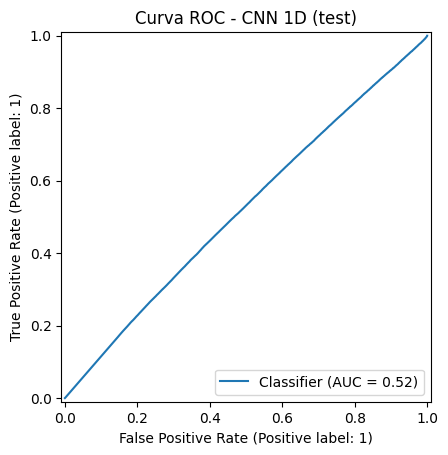

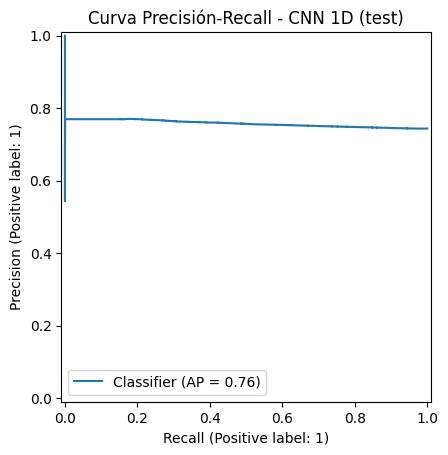

In [ ]:
model, info = train_cnn_1d(X_train.values, 
                           y_train.values, 
                           X_val.values, 
                           y_val.values, 
                           X_test.values, 
                           y_test.values)

In [ ]:
name = 'cnn1d_no_scaled'

# 1. Pesos del modelo
torch.save(model.state_dict(), base_joblib_path + f"{name}_baseline_weights.pt")

# 3. Metadata útil
checkpoint_info = {
    "best_thr": info["best_thr"],
    "best_val_pr": info["best_val_pr"],
    "input_len": X_train_scaled.shape[1],
    "architecture": "Spectral1DCNN_baseline",
    "n_classes": 2
}
torch.save(checkpoint_info, base_joblib_path + f"{name}_baseline_info.pt")

### Entrenamiento con valores escalados

Epoch 001 | loss=0.6690 | val PR-AUC=0.7977 | val ROC-AUC=0.5943
Epoch 002 | loss=0.6527 | val PR-AUC=0.8035 | val ROC-AUC=0.6021
Epoch 003 | loss=0.6450 | val PR-AUC=0.8063 | val ROC-AUC=0.6044
Epoch 004 | loss=0.6397 | val PR-AUC=0.8100 | val ROC-AUC=0.6121
Epoch 005 | loss=0.6365 | val PR-AUC=0.8045 | val ROC-AUC=0.6007
Epoch 006 | loss=0.6335 | val PR-AUC=0.8156 | val ROC-AUC=0.6184
Epoch 007 | loss=0.6307 | val PR-AUC=0.8043 | val ROC-AUC=0.6004
Epoch 008 | loss=0.6288 | val PR-AUC=0.8138 | val ROC-AUC=0.6167
Epoch 009 | loss=0.6275 | val PR-AUC=0.8140 | val ROC-AUC=0.6127
Epoch 010 | loss=0.6259 | val PR-AUC=0.8146 | val ROC-AUC=0.6192
Epoch 011 | loss=0.6244 | val PR-AUC=0.8175 | val ROC-AUC=0.6212
Epoch 012 | loss=0.6227 | val PR-AUC=0.8235 | val ROC-AUC=0.6313
Epoch 013 | loss=0.6221 | val PR-AUC=0.8215 | val ROC-AUC=0.6303
Epoch 014 | loss=0.6210 | val PR-AUC=0.8238 | val ROC-AUC=0.6326
Epoch 015 | loss=0.6201 | val PR-AUC=0.8220 | val ROC-AUC=0.6316
Epoch 016 | loss=0.6193 |

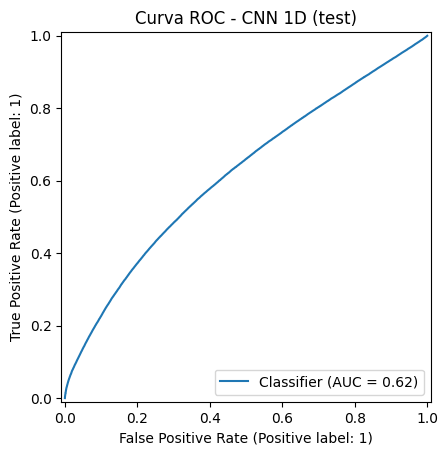

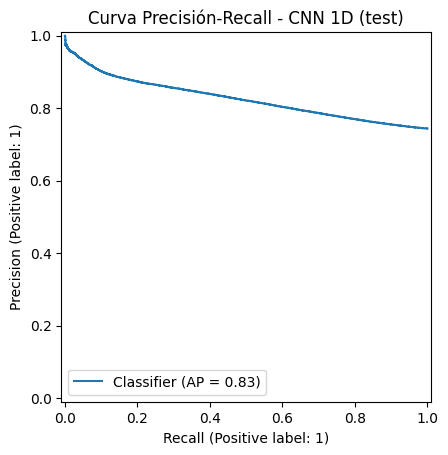

In [ ]:
model, info = train_cnn_1d(X_train_scaled, 
                           y_train.values, 
                           X_val_scaled, 
                           y_val.values, 
                           X_test_scaled, 
                           y_test.values)

In [ ]:
name = 'cnn1d_scaled'

# 1. Pesos del modelo
torch.save(model.state_dict(), base_joblib_path + f"{name}_baseline_weights.pt")

# 3. Metadata útil
checkpoint_info = {
    "best_thr": info["best_thr"],
    "best_val_pr": info["best_val_pr"],
    "input_len": X_train_scaled.shape[1],
    "architecture": "Spectral1DCNN_baseline",
    "n_classes": 2
}
torch.save(checkpoint_info, base_joblib_path + f"{name}_baseline_info.pt")


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 1. Cargar metadata
# info = torch.load(base_joblib_path + "cnn1d_baseline_info.pt", map_location=device)

# # 2. Reconstruir el modelo (MISMA arquitectura)
# model = Spectral1DCNN(
#     input_len=info["input_len"],
#     n_classes=info["n_classes"]
# ).to(device)

# # 3. Cargar pesos
# model.load_state_dict(
#     torch.load(base_joblib_path + "cnn1d_baseline_weights.pt", map_location=device)
# )

# model.eval()

# # 4. Cargar scaler
# scaler = joblib.load("checkpoints/robust_scaler.pkl")

# best_thr = info["best_thr"]


## 2.2 Optimización de hiperparámetros

In [189]:
class Spectral1DCNN(nn.Module):
    def __init__(self, input_len, n_classes=2, kernel_size=5, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2

        self.conv1 = nn.Conv1d(1, 16, kernel_size=kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(8)
        self.fc1 = nn.Linear(32 * 8, 64)
        self.fc2 = nn.Linear(64, n_classes)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)



In [190]:
def train_eval_trial(
    X_train, y_train,
    X_val, y_val,
    input_len,
    lr, batch_size, weight_decay,
    dropout, kernel_size,
    max_epochs=100,
    patience=15,
    seed=42,
    trial=None,
    verbose=False
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ----------------------------
    # DataLoaders
    # ----------------------------
    def make_loader(X, y, shuffle):
        X_t = torch.from_numpy(X.astype(np.float32)).unsqueeze(1)
        y_t = torch.from_numpy(y.astype(np.int64))
        return DataLoader(
            TensorDataset(X_t, y_t),
            batch_size=batch_size,
            shuffle=shuffle,
            pin_memory=True
        )

    train_loader = make_loader(X_train, y_train, True)
    val_loader   = make_loader(X_val,   y_val,   False)

    # ----------------------------
    # Pesos por desbalance
    # ----------------------------
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    w_pos = n_neg / max(n_pos, 1)

    class_weights = torch.tensor(
        [1.0, w_pos],
        dtype=torch.float32,
        device=device
    )

    # ----------------------------
    # Modelo
    # ----------------------------
    model = Spectral1DCNN(
        input_len=input_len,
        kernel_size=kernel_size,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # ----------------------------
    # Entrenamiento
    # ----------------------------
    best_pr = -np.inf
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):

        # ---- TRAIN ----
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # ---- VALIDATION ----
        model.eval()
        y_true, y_prob = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb.to(device, non_blocking=True))
                prob = torch.softmax(logits, dim=1)[:, 1]
                y_prob.extend(prob.cpu().numpy())
                y_true.extend(yb.numpy())

        pr = average_precision_score(y_true, y_prob)
        roc = roc_auc_score(y_true, y_prob)

        # ---- Optuna report & pruning ----
        if trial is not None:
            trial.report(pr, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if verbose:
            print(f"\tEpoch {epoch:03d} | loss={np.mean(losses):.4f} | val PR-AUC={pr:.4f} | val ROC-AUC={roc:.4f}")

        # ---- Early stopping ----
        if pr > best_pr:
            best_pr = pr
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\tEarly stopping en epoch {epoch} (mejor val PR-AUC={best_pr:.4f})")
                break

    return best_pr


### Datos escalados

In [191]:
def objective(trial):

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    kernel_size = trial.suggest_categorical("kernel_size", [3, 5, 7, 9])

    pr_auc = train_eval_trial(
        X_train_scaled, y_train.values,
        X_val_scaled,   y_val.values,
        input_len=X_train_scaled.shape[1],
        lr=lr,
        batch_size=batch_size,
        weight_decay=weight_decay,
        dropout=dropout,
        kernel_size=kernel_size,
        trial=trial,
        verbose=True
    )

    return pr_auc


In [192]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

study.optimize(objective, n_trials=30)


[I 2025-12-15 15:50:25,677] A new study created in memory with name: no-name-5e10b158-c514-4d2e-8e7c-e0ee3ab40ee5


	Epoch 001 | loss=0.6663 | val PR-AUC=0.8006 | val ROC-AUC=0.5987
	Epoch 002 | loss=0.6499 | val PR-AUC=0.8030 | val ROC-AUC=0.6006
	Epoch 003 | loss=0.6422 | val PR-AUC=0.8067 | val ROC-AUC=0.6055
	Epoch 004 | loss=0.6370 | val PR-AUC=0.8119 | val ROC-AUC=0.6132
	Epoch 005 | loss=0.6333 | val PR-AUC=0.8017 | val ROC-AUC=0.5951
	Epoch 006 | loss=0.6307 | val PR-AUC=0.8198 | val ROC-AUC=0.6245
	Epoch 007 | loss=0.6283 | val PR-AUC=0.8173 | val ROC-AUC=0.6208
	Epoch 008 | loss=0.6265 | val PR-AUC=0.8184 | val ROC-AUC=0.6232
	Epoch 009 | loss=0.6250 | val PR-AUC=0.8185 | val ROC-AUC=0.6204
	Epoch 010 | loss=0.6233 | val PR-AUC=0.8190 | val ROC-AUC=0.6259
	Epoch 011 | loss=0.6216 | val PR-AUC=0.8200 | val ROC-AUC=0.6244
	Epoch 012 | loss=0.6212 | val PR-AUC=0.8241 | val ROC-AUC=0.6312
	Epoch 013 | loss=0.6203 | val PR-AUC=0.8216 | val ROC-AUC=0.6316
	Epoch 014 | loss=0.6188 | val PR-AUC=0.8229 | val ROC-AUC=0.6320
	Epoch 015 | loss=0.6184 | val PR-AUC=0.8240 | val ROC-AUC=0.6345
	Epoch 016

[I 2025-12-15 17:03:15,128] Trial 0 finished with value: 0.8380084783662338 and parameters: {'lr': 0.00043284502212938834, 'batch_size': 64, 'weight_decay': 2.9380279387035354e-06, 'dropout': 0.24679835610086082, 'kernel_size': 5}. Best is trial 0 with value: 0.8380084783662338.


	Epoch 083 | loss=0.6004 | val PR-AUC=0.8375 | val ROC-AUC=0.6569
	Early stopping en epoch 83 (mejor val PR-AUC=0.8380)
	Epoch 001 | loss=0.6736 | val PR-AUC=0.7940 | val ROC-AUC=0.5900
	Epoch 002 | loss=0.6587 | val PR-AUC=0.7960 | val ROC-AUC=0.5937
	Epoch 003 | loss=0.6515 | val PR-AUC=0.7987 | val ROC-AUC=0.5974
	Epoch 004 | loss=0.6463 | val PR-AUC=0.8054 | val ROC-AUC=0.6067
	Epoch 005 | loss=0.6417 | val PR-AUC=0.7981 | val ROC-AUC=0.5961
	Epoch 006 | loss=0.6381 | val PR-AUC=0.8144 | val ROC-AUC=0.6188
	Epoch 007 | loss=0.6347 | val PR-AUC=0.8104 | val ROC-AUC=0.6112
	Epoch 008 | loss=0.6317 | val PR-AUC=0.8107 | val ROC-AUC=0.6128
	Epoch 009 | loss=0.6294 | val PR-AUC=0.8151 | val ROC-AUC=0.6164
	Epoch 010 | loss=0.6272 | val PR-AUC=0.8156 | val ROC-AUC=0.6184
	Epoch 011 | loss=0.6249 | val PR-AUC=0.8180 | val ROC-AUC=0.6218
	Epoch 012 | loss=0.6238 | val PR-AUC=0.8207 | val ROC-AUC=0.6259
	Epoch 013 | loss=0.6221 | val PR-AUC=0.8199 | val ROC-AUC=0.6283
	Epoch 014 | loss=0.62

[I 2025-12-15 17:55:07,403] Trial 1 finished with value: 0.8372378641201066 and parameters: {'lr': 0.00010838581269344756, 'batch_size': 64, 'weight_decay': 3.5113563139704077e-06, 'dropout': 0.2550213529560302, 'kernel_size': 5}. Best is trial 0 with value: 0.8380084783662338.


...

[I 2025-12-16 00:54:28,747] Trial 27 pruned. 


	Epoch 001 | loss=0.6712 | val PR-AUC=0.7980 | val ROC-AUC=0.5934
	Epoch 002 | loss=0.6556 | val PR-AUC=0.8018 | val ROC-AUC=0.5990
	Epoch 003 | loss=0.6491 | val PR-AUC=0.8058 | val ROC-AUC=0.6043
	Epoch 004 | loss=0.6448 | val PR-AUC=0.8028 | val ROC-AUC=0.5985
	Epoch 005 | loss=0.6416 | val PR-AUC=0.8095 | val ROC-AUC=0.6066
	Epoch 006 | loss=0.6394 | val PR-AUC=0.8120 | val ROC-AUC=0.6111
	Epoch 007 | loss=0.6377 | val PR-AUC=0.8084 | val ROC-AUC=0.6075
	Epoch 008 | loss=0.6361 | val PR-AUC=0.8183 | val ROC-AUC=0.6205
	Epoch 009 | loss=0.6349 | val PR-AUC=0.8195 | val ROC-AUC=0.6217
	Epoch 010 | loss=0.6342 | val PR-AUC=0.8169 | val ROC-AUC=0.6212


[I 2025-12-16 01:03:54,202] Trial 28 pruned. 


	Epoch 001 | loss=0.6694 | val PR-AUC=0.7950 | val ROC-AUC=0.5908
	Epoch 002 | loss=0.6528 | val PR-AUC=0.8024 | val ROC-AUC=0.6016
	Epoch 003 | loss=0.6444 | val PR-AUC=0.8054 | val ROC-AUC=0.6035
	Epoch 004 | loss=0.6387 | val PR-AUC=0.8101 | val ROC-AUC=0.6121
	Epoch 005 | loss=0.6346 | val PR-AUC=0.8039 | val ROC-AUC=0.6016
	Epoch 006 | loss=0.6310 | val PR-AUC=0.8155 | val ROC-AUC=0.6193
	Epoch 007 | loss=0.6286 | val PR-AUC=0.8083 | val ROC-AUC=0.6080
	Epoch 008 | loss=0.6261 | val PR-AUC=0.8125 | val ROC-AUC=0.6143
	Epoch 009 | loss=0.6248 | val PR-AUC=0.8120 | val ROC-AUC=0.6111


[I 2025-12-16 01:07:04,569] Trial 29 pruned. 


In [193]:
print("Best PR-AUC:", study.best_value)
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Best PR-AUC: 0.8396643471629073
Best hyperparameters:
  lr: 0.00045745782054754043
  batch_size: 128
  weight_decay: 6.963114377829292e-06
  dropout: 0.3628088249474746
  kernel_size: 9


### Entrenamiento final de la red con los mejores hiperparámetros

In [90]:
class Spectral1DCNN(nn.Module):
    def __init__(self, input_len, n_classes=2, kernel_size=5, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2

        self.conv1 = nn.Conv1d(1, 16, kernel_size=kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(8)
        self.fc1 = nn.Linear(32 * 8, 64)
        self.fc2 = nn.Linear(64, n_classes)

        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


In [91]:
# ----------------------------
# Entrenamiento y evaluación
# ----------------------------
def train_cnn_1d(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    lr=1e-3,
    batch_size=256,
    weight_decay=1e-5,
    max_epochs=200,
    patience=20,
    seed=42,
    **model_kwargs
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Tensores y loaders
    def to_loader(X, y, shuffle, bs):
        X_t = torch.from_numpy(X.astype(np.float32)).unsqueeze(1)  # [N, 1, L]
        y_t = torch.from_numpy(y.astype(np.int64))
        ds = TensorDataset(X_t, y_t)
        return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0, pin_memory=True)

    train_loader = to_loader(X_train, y_train, True, batch_size)
    val_loader   = to_loader(X_val,   y_val,   False, batch_size)
    test_loader  = to_loader(X_test,  y_test,  False, batch_size)

    # Desbalance: pesos de clase (usar solo TRAIN)
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / max(n_pos, 1)
    class_weights = torch.tensor([1.0, scale_pos_weight], dtype=torch.float32, device=device)

    # Modelo y optimizador
    input_len = X_train.shape[1]
    model = Spectral1DCNN(
                input_len=input_len,
                n_classes=2,
                **model_kwargs
            ).to(device)

    optimizer = torch.optim.Adam(
                    model.parameters(),
                    lr=lr,
                    weight_decay=weight_decay
                )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    print("Model hyperparameters:")
    print(model, '\n')

    print("Training hyperparameters:")
    print(f"lr={lr}, batch_size={batch_size}, weight_decay={weight_decay}")

    # Early stopping por AUC-PR (validación)
    best_val_pr = -np.inf
    best_state = None
    epochs_no_improve = 0
    hist_val_pr = []
    hist_val_roc = []

    for epoch in range(1, max_epochs + 1):
        # Train
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            losses.append(loss.item())
            # print(xb.device, yb.device)

        # Validación
        model.eval()
        y_true, y_prob = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                logits = model(xb)
                prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                y_prob.extend(prob)
                y_true.extend(yb.numpy())
        try:
            val_pr = average_precision_score(y_true, y_prob)  # PR-AUC
            val_roc = roc_auc_score(y_true, y_prob)
        except ValueError:
            val_pr = np.nan
            val_roc = np.nan
        hist_val_pr.append(val_pr)
        hist_val_roc.append(val_roc)

        print(f"Epoch {epoch:03d} | loss={np.mean(losses):.4f} | val PR-AUC={val_pr:.4f} | val ROC-AUC={val_roc:.4f}")

        # Early stopping
        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping en epoch {epoch} (mejor val PR-AUC={best_val_pr:.4f})")
                break

    # Restaurar mejor estado
    if best_state is not None:
        model.load_state_dict(best_state)

    # Optimizar umbral en VAL por F1 macro
    y_true_val, y_prob_val = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb.to(device, non_blocking=True))
            y_true_val.extend(yb.numpy())
            y_prob_val.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

    thr_grid = np.linspace(0.10, 0.90, 161)
    best_thr, best_f1 = max(
        ((t, f1_score(y_true_val, (np.array(y_prob_val) >= t).astype(int), average="macro")) for t in thr_grid),
        key=lambda x: x[1]
    )
    print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

    # Evaluación en TEST
    y_true_test, y_prob_test = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(device, non_blocking=True))
            y_true_test.extend(yb.numpy())
            y_prob_test.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

    y_pred_test = (np.array(y_prob_test) >= best_thr).astype(int)
    roc = roc_auc_score(y_true_test, y_prob_test)
    pr  = average_precision_score(y_true_test, y_prob_test)
    print("\n--- Reporte de clasificación (TEST) ---")
    print(classification_report(y_true_test, y_pred_test, digits=3))
    print("ROC-AUC (test):", roc)
    print("PR-AUC  (test):", pr)
    print("\nMatriz de confusión (TEST):")
    print(confusion_matrix(y_true_test, y_pred_test))

    # Curvas ROC y PR
    RocCurveDisplay.from_predictions(y_true_test, y_prob_test)
    plt.title("Curva ROC - CNN 1D (test)"); plt.show()
    PrecisionRecallDisplay.from_predictions(y_true_test, y_prob_test)
    plt.title("Curva Precisión-Recall - CNN 1D (test)"); plt.show()

    return model, {'best_val_pr': best_val_pr, 'best_thr': best_thr}

Model hyperparameters:
Spectral1DCNN(
  (conv1): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool1d(output_size=8)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
  (drop): Dropout(p=0.3628088249474746, inplace=False)
) 

Training hyperparameters:
lr=0.00045745782054754043, batch_size=128, weight_decay=6.963114377829292e-06
Epoch 001 | loss=0.6690 | val PR-AUC=0.7982 | val ROC-AUC=0.5971
Epoch 002 | loss=0.6521 | val PR-AUC=0.8032 | val ROC-AUC=0.6031
Epoch 003 | loss=0.6428 | val PR-AUC=0.8044 | val ROC-AUC=0.6051
Epoch 004 | loss=0.6376 | val PR-AUC=0.8012 | val ROC-AUC=0.5992
Epoch 005 | loss=0.6333 | val PR-AUC=0.8047 | val ROC-AUC

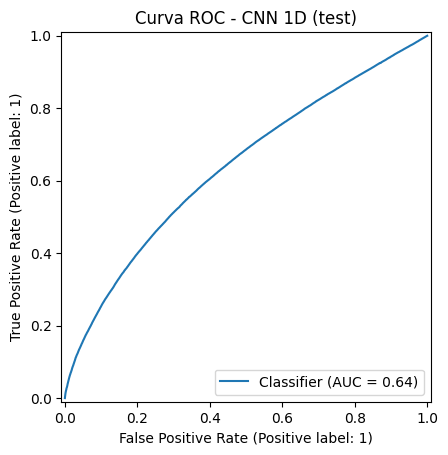

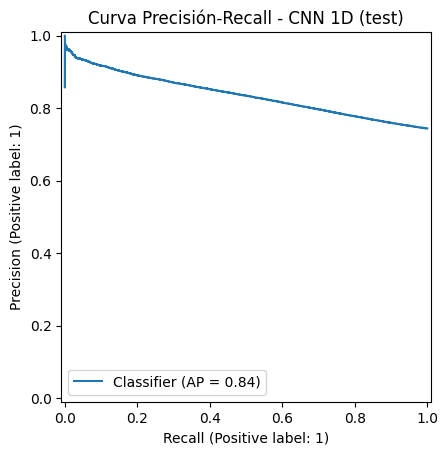

In [92]:
best_model, info = train_cnn_1d(
    X_train_scaled, y_train.values,
    X_val_scaled,   y_val.values,
    X_test_scaled,  y_test.values,

    # Optimizador / training
    lr=0.00045745782054754043,
    batch_size=128,
    weight_decay=6.963114377829292e-06,
    max_epochs=200,
    patience=25,
    seed=42,

    # Arquitectura del modelo
    kernel_size=9,
    dropout=0.3628088249474746
)



In [ ]:
name = "cnn1d_bst_prms"

# Pesos
torch.save(best_model.state_dict(),  base_joblib_path + f"{name}_weights.pt")

# Metadata completa
checkpoint_info = {
    "architecture": "Spectral1DCNN",
    "input_len": X_train_scaled.shape[1],
    "n_classes": 2,

    "model_kwargs": {
        "kernel_size": 9,
        "dropout": 0.3628088249474746
    },

    "training_kwargs": {
        "lr": 0.00045745782054754043,
        "batch_size": 128,
        "weight_decay": 6.963114377829292e-06,
        "seed": 42
    },

    "best_thr": info["best_thr"],
    "best_val_pr": info["best_val_pr"],
}

torch.save(checkpoint_info, base_joblib_path + f"{name}_metadata.pt")

### Cargar modelo guardado

In [91]:
name = "cnn1d_bst_prms"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Cargar metadata
info = torch.load(base_joblib_path + f"{name}_metadata.pt", map_location=device, weights_only=False)

# 2. Reconstruir el modelo (MISMA arquitectura)
model = Spectral1DCNN(
    input_len=info["input_len"],
    n_classes=info["n_classes"],
    kernel_size=info['model_kwargs']['kernel_size'],
    dropout=info['model_kwargs']['dropout']
).to(device)

# 3. Cargar pesos
model.load_state_dict(
    torch.load(base_joblib_path + f"{name}_weights.pt", map_location=device, weights_only=False)
)

model.eval()

best_thr = info["best_thr"]
best_val_pr = info["best_val_pr"]
batch_size = info['training_kwargs']['batch_size']

In [92]:
info

{'architecture': 'Spectral1DCNN',
 'input_len': 63,
 'n_classes': 2,
 'model_kwargs': {'kernel_size': 9, 'dropout': 0.3628088249474746},
 'training_kwargs': {'lr': 0.00045745782054754043,
  'batch_size': 128,
  'weight_decay': 6.963114377829292e-06,
  'seed': 42},
 'best_thr': np.float64(0.42000000000000004),
 'best_val_pr': 0.8418172057378266}

In [93]:
model

Spectral1DCNN(
  (conv1): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool1d(output_size=8)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
  (drop): Dropout(p=0.3628088249474746, inplace=False)
)


--- Reporte de clasificación (TEST) ---
              precision    recall  f1-score   support

           0      0.356     0.479     0.408     92596
           1      0.797     0.702     0.746    269214

    accuracy                          0.645    361810
   macro avg      0.576     0.590     0.577    361810
weighted avg      0.684     0.645     0.660    361810

ROC-AUC (test): 0.6393328123973856
PR-AUC  (test): 0.8366492177641778

Matriz de confusión (TEST):
[[ 44317  48279]
 [ 80194 189020]]


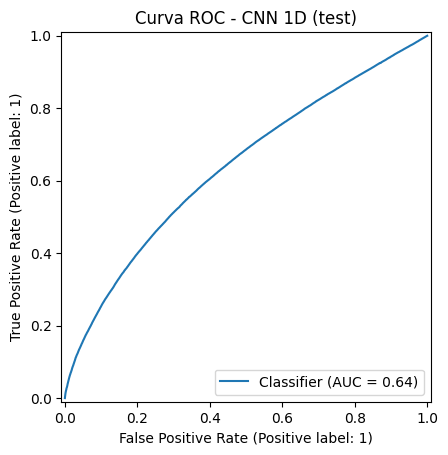

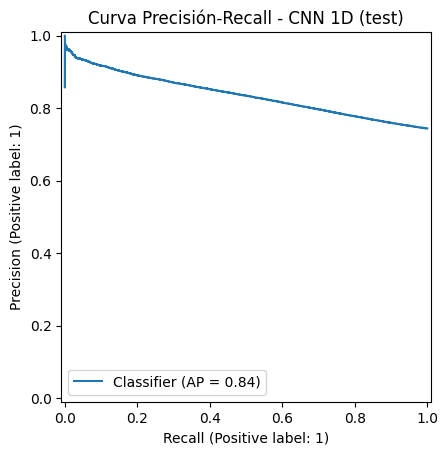

In [ ]:
# Tensores y loaders
def to_loader(X, y, shuffle, bs):
    X_t = torch.from_numpy(X.astype(np.float32)).unsqueeze(1)  # [N, 1, L]
    y_t = torch.from_numpy(y.astype(np.int64))
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0, pin_memory=True)

test_loader  = to_loader(X_test_scaled,  y_test.values, False, batch_size)

# Evaluación en TEST
y_true_test, y_prob_test = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(device, non_blocking=True))
        y_true_test.extend(yb.numpy())
        y_prob_test.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

y_pred_test = (np.array(y_prob_test) >= best_thr).astype(int)
roc = roc_auc_score(y_true_test, y_prob_test)
pr  = average_precision_score(y_true_test, y_prob_test)
print("\n--- Reporte de clasificación (TEST) ---")
print(classification_report(y_true_test, y_pred_test, digits=3))
print("ROC-AUC (test):", roc)
print("PR-AUC  (test):", pr)
print("\nMatriz de confusión (TEST):")
print(confusion_matrix(y_true_test, y_pred_test))

# Curvas ROC y PR
RocCurveDisplay.from_predictions(y_true_test, y_prob_test)
plt.title("Curva ROC - CNN 1D (test)"); plt.show()
PrecisionRecallDisplay.from_predictions(y_true_test, y_prob_test)
plt.title("Curva Precisión-Recall - CNN 1D (test)"); plt.show()

In [95]:
44317+ 189020

233337

In [96]:
y_test

1204447     1.0
1204448     1.0
1207884     1.0
1207885     1.0
1207886     1.0
           ... 
10277822    0.0
10277823    0.0
10281258    0.0
10281259    0.0
10281260    0.0
Name: label, Length: 361810, dtype: float64

In [97]:
y_test.values

array([1., 1., 1., ..., 0., 0., 0.], shape=(361810,))

### Gráfico Real VS Predicción (Test)

In [98]:
a = np.array(y_true_test)
a

array([1, 1, 1, ..., 0, 0, 0], shape=(361810,))

In [99]:
a == y_test.values

array([ True,  True,  True, ...,  True,  True,  True], shape=(361810,))

In [100]:
(y_pred_test == a).sum() # Debe dar la diagonal de la matriz

np.int64(233337)

In [101]:
y_pred_test_serie = pd.Series(y_pred_test, index=y_test.index)
y_pred_test_serie

1204447     1
1204448     1
1207884     1
1207885     1
1207886     1
           ..
10277822    1
10277823    1
10281258    1
10281259    1
10281260    1
Length: 361810, dtype: int64

In [102]:
(y_pred_test_serie == y_test).sum() # Debe dar la diagonal de la matriz

np.int64(233337)

In [103]:
y_copy = y.copy()

In [104]:
y_copy[y_test.index]

1204447     1.0
1204448     1.0
1207884     1.0
1207885     1.0
1207886     1.0
           ... 
10277822    0.0
10277823    0.0
10281258    0.0
10281259    0.0
10281260    0.0
Name: label, Length: 361810, dtype: float64

In [105]:
y_copy[y_test.index] = y_pred_test

In [106]:
y_copy[y_test.index]

1204447     1.0
1204448     1.0
1207884     1.0
1207885     1.0
1207886     1.0
           ... 
10277822    1.0
10277823    1.0
10281258    1.0
10281259    1.0
10281260    1.0
Name: label, Length: 361810, dtype: float64

In [107]:
X

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,0.000002,0.000003,...,1.170000e-06,1.260000e-06,1.210000e-06,1.410000e-06,0.000001,0.000001,1.520000e-06,1.080000e-06,1.170000e-06,1.680000e-06
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,0.000003,0.000004,...,1.200000e-06,1.350000e-06,1.360000e-06,1.320000e-06,0.000001,0.000001,1.440000e-06,1.240000e-06,1.590000e-06,2.570000e-06
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,0.000002,0.000002,...,1.930000e-06,1.870000e-06,1.480000e-06,1.450000e-06,0.000001,0.000001,1.220000e-06,1.420000e-06,9.300000e-07,2.120000e-06
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,0.000003,0.000004,...,1.320000e-06,1.350000e-06,1.200000e-06,1.120000e-06,0.000001,0.000001,1.200000e-06,1.210000e-06,1.060000e-06,2.730000e-06
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,0.000003,0.000004,...,9.200000e-07,1.040000e-06,1.070000e-06,1.190000e-06,0.000001,0.000001,1.160000e-06,7.899999e-07,1.460000e-06,2.730000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.888521,0.366129,7.144231,-0.015290,0.001305,5.000000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,9.700000e-07,8.600001e-07,1.020000e-06,1.350000e-06,0.000002,0.000001,1.430000e-06,9.900000e-07,1.470000e-06,1.700000e-06
11264514,0.882600,0.398624,8.368794,-0.027027,0.003433,4.900000e-07,2.500000e-07,3.300000e-07,0.000001,0.000001,...,1.410000e-06,1.350000e-06,1.380000e-06,1.600000e-06,0.000002,0.000001,8.600001e-07,5.700000e-07,9.500000e-07,2.020000e-06
11267949,0.861718,0.342920,5.820225,0.004504,0.000000,7.899999e-07,7.200000e-07,8.400000e-07,0.000002,0.000003,...,1.250000e-06,1.270000e-06,1.160000e-06,9.700000e-07,0.000001,0.000001,9.500000e-07,1.200000e-06,1.250000e-06,1.180000e-06
11267950,0.844688,0.332175,5.390000,0.000000,-0.001731,7.800000e-07,9.500000e-07,1.080000e-06,0.000003,0.000003,...,1.190000e-06,1.480000e-06,1.310000e-06,8.100000e-07,0.000001,0.000001,1.030000e-06,1.530000e-06,5.200000e-07,8.300000e-07


In [108]:
y_copy

1204447     1.0
1204448     1.0
1207884     1.0
1207885     1.0
1207886     1.0
           ... 
11264513    0.0
11264514    0.0
11267949    0.0
11267950    0.0
11267951    0.0
Name: label, Length: 1714264, dtype: float64

In [109]:
data_pred = pd.DataFrame(data).copy()
data_pred

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12583075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12583076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12583077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12583078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
data_pred.loc[y_test.index]

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,2.490000e-06,0.000003,...,1.210000e-06,1.410000e-06,1.490000e-06,1.500000e-06,1.520000e-06,1.080000e-06,1.170000e-06,0.000002,1.0,3.0
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,2.960000e-06,0.000004,...,1.360000e-06,1.320000e-06,1.300000e-06,1.280000e-06,1.440000e-06,1.240000e-06,1.590000e-06,0.000003,1.0,3.0
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,1.690000e-06,0.000002,...,1.480000e-06,1.450000e-06,1.390000e-06,1.410000e-06,1.220000e-06,1.420000e-06,9.300000e-07,0.000002,1.0,3.0
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,3.000000e-06,0.000004,...,1.200000e-06,1.120000e-06,1.290000e-06,1.360000e-06,1.200000e-06,1.210000e-06,1.060000e-06,0.000003,1.0,3.0
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,3.310000e-06,0.000004,...,1.070000e-06,1.190000e-06,1.380000e-06,1.350000e-06,1.160000e-06,7.899999e-07,1.460000e-06,0.000003,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10277822,0.902115,0.388178,8.611814,0.010929,0.001931,5.800000e-07,6.300000e-07,7.000000e-07,1.850000e-06,0.000002,...,6.400000e-07,6.300000e-07,6.100000e-07,8.600001e-07,6.000000e-07,6.700000e-07,1.320000e-06,0.000002,0.0,3.0
10277823,0.901296,0.381144,8.506383,0.000000,0.000486,6.700000e-07,5.900000e-07,7.200000e-07,1.830000e-06,0.000002,...,7.200000e-07,6.600000e-07,4.800000e-07,7.800000e-07,7.500000e-07,8.400000e-07,1.060000e-06,0.000002,0.0,3.0
10281258,0.863384,0.385475,9.238532,-0.017341,0.008499,4.200000e-07,2.300000e-07,2.900000e-07,8.500000e-07,0.000001,...,1.090000e-06,1.200000e-06,1.270000e-06,1.140000e-06,1.000000e-06,6.000000e-07,1.140000e-06,0.000002,0.0,3.0
10281259,0.891209,0.385191,9.090909,0.000000,0.002556,4.600000e-07,3.900000e-07,4.500000e-07,1.300000e-06,0.000002,...,1.240000e-06,1.310000e-06,1.200000e-06,1.010000e-06,7.400000e-07,4.000000e-07,1.070000e-06,0.000002,0.0,3.0


In [111]:
data_pred.loc[y_test.index, 63] = y_pred_test

In [112]:
data_pred.loc[y_test.index]

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,2.490000e-06,0.000003,...,1.210000e-06,1.410000e-06,1.490000e-06,1.500000e-06,1.520000e-06,1.080000e-06,1.170000e-06,0.000002,1.0,3.0
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,2.960000e-06,0.000004,...,1.360000e-06,1.320000e-06,1.300000e-06,1.280000e-06,1.440000e-06,1.240000e-06,1.590000e-06,0.000003,1.0,3.0
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,1.690000e-06,0.000002,...,1.480000e-06,1.450000e-06,1.390000e-06,1.410000e-06,1.220000e-06,1.420000e-06,9.300000e-07,0.000002,1.0,3.0
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,3.000000e-06,0.000004,...,1.200000e-06,1.120000e-06,1.290000e-06,1.360000e-06,1.200000e-06,1.210000e-06,1.060000e-06,0.000003,1.0,3.0
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,3.310000e-06,0.000004,...,1.070000e-06,1.190000e-06,1.380000e-06,1.350000e-06,1.160000e-06,7.899999e-07,1.460000e-06,0.000003,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10277822,0.902115,0.388178,8.611814,0.010929,0.001931,5.800000e-07,6.300000e-07,7.000000e-07,1.850000e-06,0.000002,...,6.400000e-07,6.300000e-07,6.100000e-07,8.600001e-07,6.000000e-07,6.700000e-07,1.320000e-06,0.000002,1.0,3.0
10277823,0.901296,0.381144,8.506383,0.000000,0.000486,6.700000e-07,5.900000e-07,7.200000e-07,1.830000e-06,0.000002,...,7.200000e-07,6.600000e-07,4.800000e-07,7.800000e-07,7.500000e-07,8.400000e-07,1.060000e-06,0.000002,1.0,3.0
10281258,0.863384,0.385475,9.238532,-0.017341,0.008499,4.200000e-07,2.300000e-07,2.900000e-07,8.500000e-07,0.000001,...,1.090000e-06,1.200000e-06,1.270000e-06,1.140000e-06,1.000000e-06,6.000000e-07,1.140000e-06,0.000002,1.0,3.0
10281259,0.891209,0.385191,9.090909,0.000000,0.002556,4.600000e-07,3.900000e-07,4.500000e-07,1.300000e-06,0.000002,...,1.240000e-06,1.310000e-06,1.200000e-06,1.010000e-06,7.400000e-07,4.000000e-07,1.070000e-06,0.000002,1.0,3.0


In [113]:
data_pred.loc[y_test.index, 64].unique()

array([3.])

In [114]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [115]:
labels_test = np.where(split_id == 3, labels_bin, np.nan)
labels_test

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

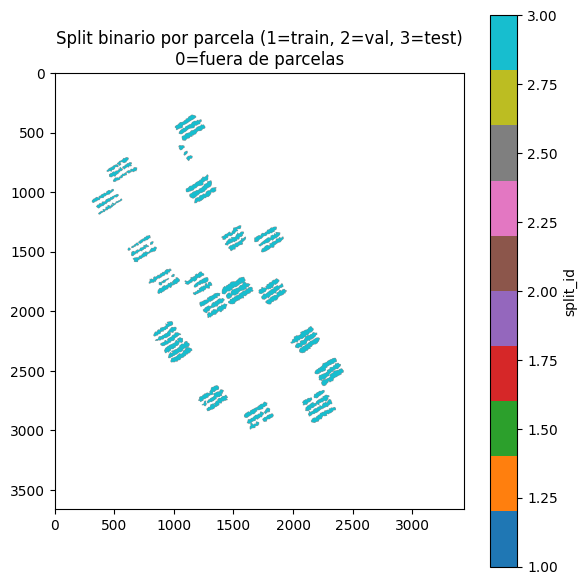

Conteo de píxeles por split: {np.uint8(1): np.int64(1038541), np.uint8(2): np.int64(353211), np.uint8(3): np.int64(372966)}


In [116]:
plt.figure(figsize=(6,6))
plt.imshow(np.where(split_id!=3, np.nan, split_id), cmap="tab10", vmin=1, vmax=3)
plt.title("Split binario por parcela (1=train, 2=val, 3=test)\n0=fuera de parcelas")
plt.colorbar(label="split_id")
plt.tight_layout()
plt.show()

# Conteo de píxeles por split dentro de parcelas
vals, counts = np.unique(split_id[split_id>0], return_counts=True)
print("Conteo de píxeles por split:", dict(zip(vals, counts)))

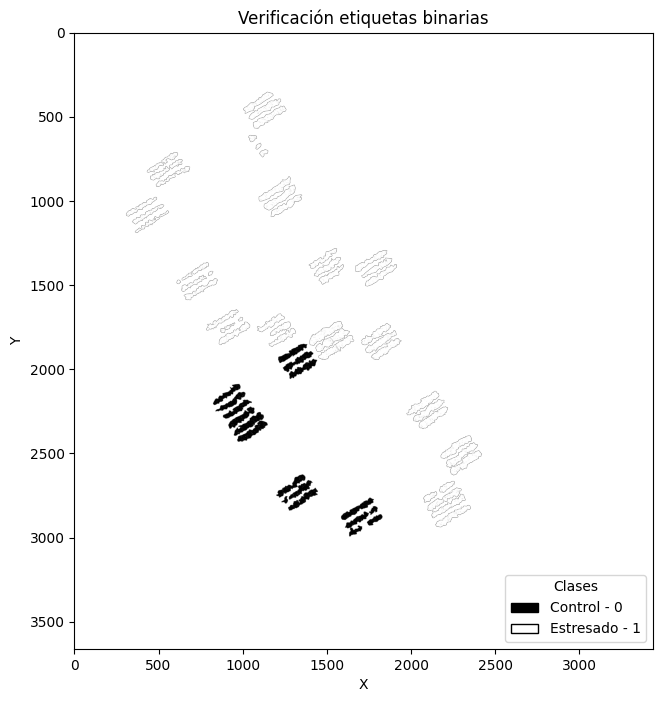

In [117]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_test, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

In [220]:
H, W = labels_bin.shape  # (3660, 3438)

In [221]:
labels_bin_pred = data_pred[63].values.reshape(H,W)
labels_bin_pred

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [222]:
labels_pred_test = np.where(split_id == 3, labels_bin_pred, np.nan)
labels_pred_test

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

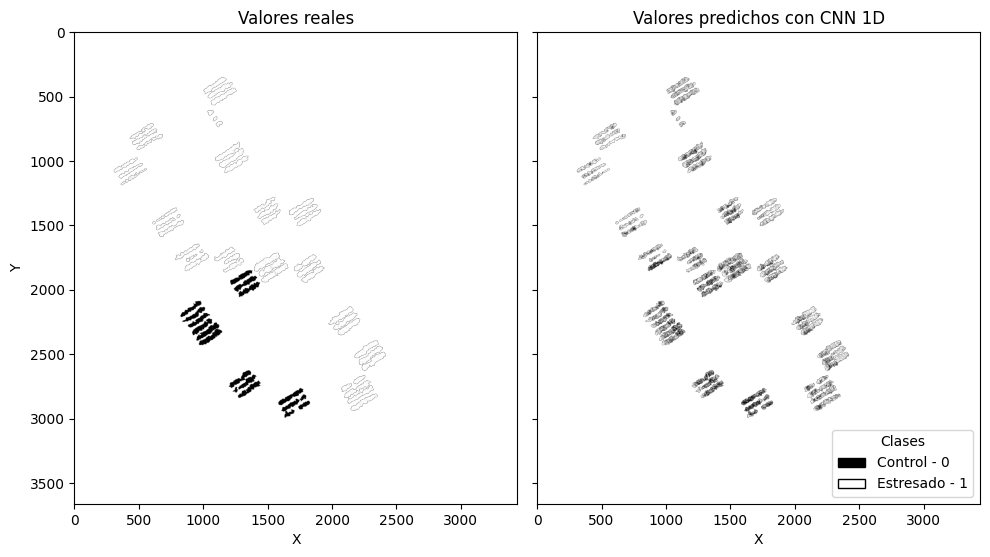

In [223]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8), sharey=True)
ax = ax.flatten()
ax[0].imshow(labels_test, cmap="gray", extent=extent, origin="upper")
ax[1].imshow(labels_pred_test, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]

ax[1].legend(handles=legend_elements, title="Clases", loc="lower right")

ax[1].set_title("Valores predichos con CNN 1D")
ax[0].set_title("Valores reales")
ax[0].set_xlabel("X")
ax[1].set_xlabel("X")
ax[0].set_ylabel("Y")
fig.tight_layout()
plt.show()

2️⃣ Qué logró (y qué no) tu CNN 1D
✔️ Lo que ya demostraste con la CNN 1D

Tu modelo 1D:

Aprende firmas espectrales discriminantes

Tiene PR-AUC alto (~0.84) → excelente para clases desbalanceadas

Funciona bien como clasificador pixel-wise

Esto te permite afirmar con solidez:

“Existe información espectral suficiente para distinguir estados fisiológicos del cultivo.”

Eso es un resultado muy fuerte.

❌ Lo que la CNN 1D NO puede aprender (por diseño)

Aunque la 1D sea buena, no puede:

Saber si un píxel está rodeado de otros similares

Suavizar predicciones ruidosas

Diferenciar:

ruido espectral

vs estrés real espacialmente coherente

Por eso, aunque el PR-AUC sea alto, visualmente:

verás “sal y pimienta”

falsos positivos aislados

bordes mal clasificados

Y eso ya se intuye en la imagen.

“Dado que el estrés fisiológico del cultivo se manifiesta como patrones espacialmente coherentes, se evaluó la incorporación progresiva de contexto espacial sobre un modelo espectral base, evitando arquitecturas 3D complejas debido a su alto costo computacional.”

“La CNN 1D mostró un desempeño notable en la identificación de parcelas control, evidenciado por una alta coherencia espacial y baja tasa de falsos positivos. Sin embargo, la clasificación de parcelas estresadas presentó fragmentación espacial y una mayor proporción de falsos negativos. Este comportamiento se atribuye a la naturaleza estrictamente espectral del modelo 1D, que no incorpora información espacial ni relaciones entre píxeles vecinos, lo cual limita su capacidad para modelar la heterogeneidad intra-parcela observada en cultivos reales.”

# 3. Modelado con CNN 2D

## 3.1 Organizar data de entrada 2D

In [57]:
print("""
      Vamos a desarrollar una CNN 3D -> 2D
    - Leer acerca de ellas en los papers durante 20 minutos,
    - Luego pediremos a copilot que nos ayude a modificar la arquitectura 1D y a transformarla. 
    
    Objetivo: Antes de irnos para el gym dejemos corriendo mínimamente una ejecución de prueba e idealmente una optimización de la CNN 2D"""
)


      Vamos a desarrollar una CNN 3D -> 2D
    - Leer acerca de ellas en los papers durante 20 minutos,
    - Luego pediremos a copilot que nos ayude a modificar la arquitectura 1D y a transformarla. 

    Objetivo: Antes de irnos para el gym dejemos corriendo mínimamente una ejecución de prueba e idealmente una optimización de la CNN 2D


In [58]:
mlflow.set_experiment("cnn2d")

<Experiment: artifact_location='mlflow-artifacts:/f2aaa2bca24349ab976f5bbd4eb65b3b', creation_time=1767626082824, experiment_id='2', last_update_time=1767626082824, lifecycle_stage='active', name='cnn2d', tags={}>

In [59]:
X2.shape

(12583080, 63)

In [60]:
X2_scaled = scaler.transform(X2)

In [61]:
H, W = split_id.shape
n_bands = X2.shape[1]

cube_scaled = X2_scaled.reshape(H, W, n_bands)


In [62]:
iy, ix = 1000, 2000

flat_idx = np.ravel_multi_index((iy, ix), (3660, 3438))

orig_flat_pixel = X2[flat_idx]
scaled_flat_pixel = X2_scaled[flat_idx]

reconstructed_pixel = cube_scaled[iy, ix, :]

assert np.allclose(scaled_flat_pixel, reconstructed_pixel)


In [63]:
cube_scaled

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan

In [64]:
split_2d = np.where(split_id==0, np.nan, split_id)

In [96]:
def build_patch_dataset(cube, labels_2d, split_2d, split_value, patch=7):
    """
    split_value: 1=train, 2=val, 3=test
    return: X_patches, y_vec
    """
    H, W, B = cube.shape
    r = patch // 2

    X_list = []
    y_list = []

    for i in range(r, H - r):
        for j in range(r, W - r):

            if split_2d[i, j] != split_value:
                continue

            if np.isnan(labels_2d[i, j]):
                continue

            patch_cube = cube[i-r:i+r+1, j-r:j+r+1, :]  # (p,p,B)

            if np.isnan(patch_cube).any():
                continue

            # reshape to PyTorch expected format: C,H,W
            patch_chw = np.transpose(patch_cube, (2, 0, 1))  # (B,p,p)

            X_list.append(patch_chw)
            y_list.append(labels_2d[i, j])

    X_arr = np.stack(X_list)
    y_arr = np.array(y_list, dtype=np.int64)

    return X_arr, y_arr


In [71]:
class SpectralSpatialCNN2D(nn.Module):
    def __init__(self, n_channels=63, n_classes=2, dropout=0.3, kernel_size=3):
        super().__init__()

        self.conv1 = nn.Conv2d(n_channels, 32, kernel_size=kernel_size, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        self.fc1 = nn.Linear(128 * 2 * 2, 128)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)

        return self.fc2(x)
    
def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.from_numpy(X.astype(np.float32))
    y_t = torch.from_numpy(y.astype(np.int64))
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)



In [68]:
def train_cnn_2d(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    lr=1e-3,
    batch_size=64,
    max_epochs=100,
    patience=15,
    weight_decay=1e-5,
    seed=42,
    dropout=0.3
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader   = make_loader(X_val,   y_val,   batch_size=batch_size, shuffle=False)
    test_loader  = make_loader(X_test,  y_test,  batch_size=batch_size, shuffle=False)

    # -----------------------------
    # Modelo
    # -----------------------------
    model = SpectralSpatialCNN2D(
        n_channels=X_train.shape[1],
        dropout=dropout
    ).to(device)

    # -----------------------------
    # Pesos por desbalanceo
    # -----------------------------
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / max(n_pos, 1)

    class_weights = torch.tensor(
        [1.0, scale_pos_weight],
        device=device,
        dtype=torch.float32
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_pr = -np.inf
    best_state = None
    patience_ctr = 0

    # ============================
    #         TRAINING LOOP
    # ============================
    for epoch in range(1, max_epochs+1):

        # ---------- TRAIN ----------
        model.train()
        losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        # ---------- VALID ----------
        model.eval()
        y_true, y_score = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

                y_true.extend(yb.numpy())
                y_score.extend(prob)

        val_pr = average_precision_score(y_true, y_score)
        val_roc = roc_auc_score(y_true, y_score)

        print(f"Epoch {epoch:03d} | loss={np.mean(losses):.4f} | val PR-AUC={val_pr:.4f} | val ROC-AUC={val_roc:.4f}")

        # early stopping
        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping (mejor val PR-AUC={best_val_pr:.4f})")
                break

    # -----------------------------
    # Restaurar mejor modelo
    # -----------------------------
    if best_state is not None:
        model.load_state_dict(best_state)

    # ============================
    #    UMBRAL ÓPTIMO EN VALIDACIÓN
    # ============================
    model.eval()
    y_true_val, y_prob_val = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            prob = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()

            y_true_val.extend(yb.numpy())
            y_prob_val.extend(prob)

    thr_grid = np.linspace(0.10, 0.90, 161)

    best_thr, best_f1 = max(
        (
            (t, f1_score(y_true_val, (np.array(y_prob_val) >= t).astype(int), average="macro"))
            for t in thr_grid
        ),
        key=lambda x: x[1]
    )

    print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

    # ============================
    #           TEST
    # ============================
    y_true_test, y_prob_test = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            prob = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()

            y_true_test.extend(yb.numpy())
            y_prob_test.extend(prob)

    y_true_test = np.array(y_true_test)
    y_prob_test = np.array(y_prob_test)

    y_pred_test = (y_prob_test >= best_thr).astype(int)

    roc = roc_auc_score(y_true_test, y_prob_test)
    pr  = average_precision_score(y_true_test, y_prob_test)

    print("\n--- Reporte de clasificación (TEST) ---")
    print(classification_report(y_true_test, y_pred_test, digits=3))
    print("ROC-AUC (test):", roc)
    print("PR-AUC  (test):", pr)

    print("\nMatriz de confusión (TEST):")
    print(confusion_matrix(y_true_test, y_pred_test))

    # Curvas ROC y PR
    RocCurveDisplay.from_predictions(y_true_test, y_prob_test)
    plt.title("Curva ROC - CNN 2D (test)")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_true_test, y_prob_test)
    plt.title("Curva Precisión-Recall - CNN 2D (test)")
    plt.show()

    return model, {'best_val_pr': best_val_pr, 'best_thr': best_thr}


## 3.2 Tamanio del parche = 5

In [100]:
PATCH = 5  # puedes probar 7, 9, 11
R = PATCH // 2

R

2

In [101]:
# Extraer valores
X = features_stack.where(valid_pixels)
X

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<where, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [102]:
X.shape

(3660, 3438, 63)

In [103]:
cube_scaled.shape

(3660, 3438, 63)

In [104]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [105]:
split_2d

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [106]:
# # Con datos originales sin escalar

# X_train2d, y_train2d = build_patch_dataset(X.values, labels_bin, split_2d, split_value=1, patch=PATCH)
# X_val2d,   y_val2d   = build_patch_dataset(X.values, labels_bin, split_2d, split_value=2, patch=PATCH)
# X_test2d,  y_test2d  = build_patch_dataset(X.values, labels_bin, split_2d, split_value=3, patch=PATCH)

# # Con datos escalados a partir del robustScaler entrenado únicamente en train

X_train2d, y_train2d = build_patch_dataset(cube_scaled, labels_bin, split_2d, split_value=1, patch=PATCH)
X_val2d,   y_val2d   = build_patch_dataset(cube_scaled, labels_bin, split_2d, split_value=2, patch=PATCH)
X_test2d,  y_test2d  = build_patch_dataset(cube_scaled, labels_bin, split_2d, split_value=3, patch=PATCH)

print(X_train2d.shape)  # (N, 63, P, P)


(717464, 63, 5, 5)


Epoch 001 | loss=0.4879 | val PR-AUC=0.9368 | val ROC-AUC=0.8396
Epoch 002 | loss=0.3732 | val PR-AUC=0.9524 | val ROC-AUC=0.8753
Epoch 003 | loss=0.3189 | val PR-AUC=0.9601 | val ROC-AUC=0.8920
Epoch 004 | loss=0.2852 | val PR-AUC=0.9669 | val ROC-AUC=0.9088
Epoch 005 | loss=0.2610 | val PR-AUC=0.9620 | val ROC-AUC=0.8967
Epoch 006 | loss=0.2441 | val PR-AUC=0.9649 | val ROC-AUC=0.9025
Epoch 007 | loss=0.2274 | val PR-AUC=0.9642 | val ROC-AUC=0.9025
Epoch 008 | loss=0.2149 | val PR-AUC=0.9614 | val ROC-AUC=0.8927
Epoch 009 | loss=0.2034 | val PR-AUC=0.9642 | val ROC-AUC=0.9034
Epoch 010 | loss=0.1933 | val PR-AUC=0.9620 | val ROC-AUC=0.9007
Epoch 011 | loss=0.1849 | val PR-AUC=0.9679 | val ROC-AUC=0.9131
Epoch 012 | loss=0.1777 | val PR-AUC=0.9597 | val ROC-AUC=0.8937
Epoch 013 | loss=0.1710 | val PR-AUC=0.9645 | val ROC-AUC=0.9038
Epoch 014 | loss=0.1639 | val PR-AUC=0.9624 | val ROC-AUC=0.9016
Epoch 015 | loss=0.1586 | val PR-AUC=0.9614 | val ROC-AUC=0.8961
Epoch 016 | loss=0.1538 |

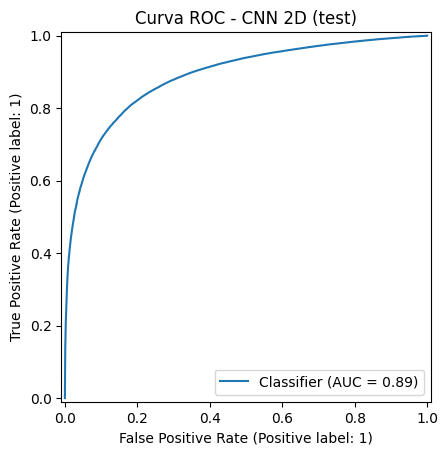

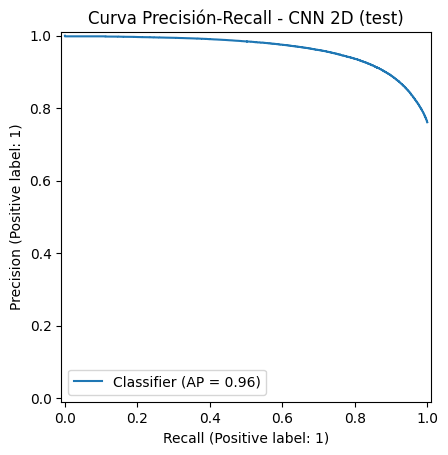

In [ ]:
model2d, info = train_cnn_2d(
    X_train2d, y_train2d,
    X_val2d,   y_val2d,
    X_test2d,  y_test2d,
    lr=1e-3,
    batch_size=64,
    max_epochs=80,
    patience=12,
    weight_decay=1e-5,
    dropout=0.3
)

In [ ]:
# name = f'cnn2d_{PATCH}_size_scaled'

# torch.save(model2d.state_dict(), base_joblib_path + f"{name}_baseline_weights.pt")

# checkpoint_info = {
#     "best_thr": info["best_thr"],
#     "best_val_pr": info["best_val_pr"],
#     "patch_size": PATCH,
#     "n_channels": X_train2d.shape[1],  # debería ser 63
#     "architecture": "SpectralSpatialCNN2D_baseline",
#     "n_classes": 2
# }

# torch.save(checkpoint_info, base_joblib_path + f"{name}_baseline_info.pt")

## 3.3 Tamanio del parche = 3

In [95]:
PATCH = 3  # puedes probar 7, 9, 11
R = PATCH // 2

In [96]:
# # Con datos escalados a partir del robustScaler entrenado únicamente en train

X_train2d, y_train2d = build_patch_dataset(cube_scaled, labels_bin, split_2d, split_value=1, patch=PATCH)
X_val2d,   y_val2d   = build_patch_dataset(cube_scaled, labels_bin, split_2d, split_value=2, patch=PATCH)
X_test2d,  y_test2d  = build_patch_dataset(cube_scaled, labels_bin, split_2d, split_value=3, patch=PATCH)

print(X_train2d.shape)  # (N, 63, P, P)

(892042, 63, 3, 3)


Epoch 001 | loss=0.5782 | val PR-AUC=0.8821 | val ROC-AUC=0.7314
Epoch 002 | loss=0.5141 | val PR-AUC=0.8995 | val ROC-AUC=0.7653
Epoch 003 | loss=0.4743 | val PR-AUC=0.9146 | val ROC-AUC=0.7935
Epoch 004 | loss=0.4462 | val PR-AUC=0.9218 | val ROC-AUC=0.8100
Epoch 005 | loss=0.4274 | val PR-AUC=0.9265 | val ROC-AUC=0.8170
Epoch 006 | loss=0.4126 | val PR-AUC=0.9271 | val ROC-AUC=0.8177
Epoch 007 | loss=0.4006 | val PR-AUC=0.9334 | val ROC-AUC=0.8374
Epoch 008 | loss=0.3907 | val PR-AUC=0.9312 | val ROC-AUC=0.8305
Epoch 009 | loss=0.3825 | val PR-AUC=0.9361 | val ROC-AUC=0.8410
Epoch 010 | loss=0.3757 | val PR-AUC=0.9346 | val ROC-AUC=0.8389
Epoch 011 | loss=0.3693 | val PR-AUC=0.9310 | val ROC-AUC=0.8287
Epoch 012 | loss=0.3635 | val PR-AUC=0.9353 | val ROC-AUC=0.8408
Epoch 013 | loss=0.3581 | val PR-AUC=0.9331 | val ROC-AUC=0.8349
Epoch 014 | loss=0.3539 | val PR-AUC=0.9364 | val ROC-AUC=0.8427
Epoch 015 | loss=0.3501 | val PR-AUC=0.9319 | val ROC-AUC=0.8319
Epoch 016 | loss=0.3463 |

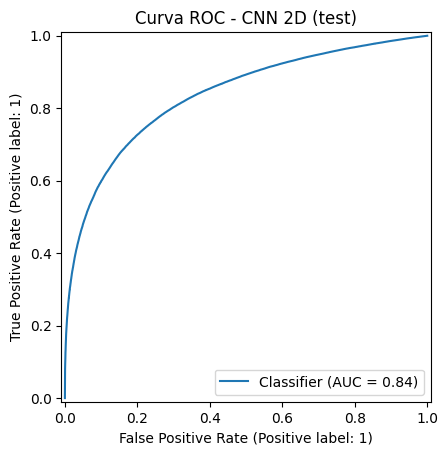

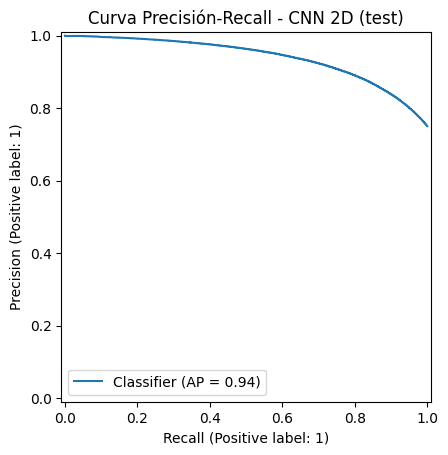

In [97]:
model2d, info = train_cnn_2d(
    X_train2d, y_train2d,
    X_val2d,   y_val2d,
    X_test2d,  y_test2d,
    lr=1e-3,
    batch_size=64,
    max_epochs=80,
    patience=12,
    weight_decay=1e-5,
    dropout=0.3
)

In [ ]:
# name = f'cnn2d_{PATCH}_size_scaled'

# torch.save(model2d.state_dict(), base_joblib_path + f"{name}_baseline_weights.pt")

# checkpoint_info = {
#     "best_thr": info["best_thr"],
#     "best_val_pr": info["best_val_pr"],
#     "patch_size": PATCH,
#     "n_channels": X_train2d.shape[1],  # debería ser 63
#     "architecture": "SpectralSpatialCNN2D_baseline",
#     "n_classes": 2
# }

# torch.save(checkpoint_info, base_joblib_path + f"{name}_baseline_info.pt")


## 3.4 Optimización hiperparámetros (Patch = 5)

In [75]:
class SpectralSpatialCNN2D(nn.Module):
    def __init__(self, n_channels=63, n_classes=2, dropout=0.3, kernel_size=3):
        super().__init__()

        pad = kernel_size // 2   # <<< SAME PADDING

        self.conv1 = nn.Conv2d(n_channels, 32, kernel_size=kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=pad)
        self.bn3 = nn.BatchNorm2d(128)

        # salida espacial ya no colapsa antes de tiempo
        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        self.fc1 = nn.Linear(128 * 2 * 2, 128)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)

        return self.fc2(x)

In [76]:
def build_patch_dataset_with_coords(cube, labels_2d, split_2d, split_value, patch=7):
    H, W, B = cube.shape
    r = patch // 2

    X_list = []
    y_list = []
    coords = []  # <- NUEVO

    for i in range(r, H - r):
        for j in range(r, W - r):

            if split_2d[i, j] != split_value:
                continue
            if np.isnan(labels_2d[i, j]):
                continue

            patch_cube = cube[i-r:i+r+1, j-r:j+r+1, :]
            if np.isnan(patch_cube).any():
                continue

            patch_chw = np.transpose(patch_cube, (2, 0, 1))

            X_list.append(patch_chw)
            y_list.append(labels_2d[i, j])
            coords.append((i, j))  # <- guardamos posición del píxel central

    X_arr = np.stack(X_list)
    y_arr = np.array(y_list, dtype=np.int64)

    return X_arr, y_arr, np.array(coords)

In [77]:
def train_eval_trial_2d(
    X_train, y_train,
    X_val, y_val,
    lr, batch_size, weight_decay,
    dropout, kernel_size,
    max_epochs=80,
    patience=10,
    seed=42,
    trial=None,
    verbose=False
):

    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ----------------------------
    # DataLoaders
    # ----------------------------
    def make_loader(X, y, shuffle):
        X_t = torch.from_numpy(X.astype(np.float32))
        y_t = torch.from_numpy(y.astype(np.int64))
        ds = TensorDataset(X_t, y_t)
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(X_train, y_train, True)
    val_loader   = make_loader(X_val,   y_val,   False)

    # ----------------------------
    # Pesos por desbalance
    # ----------------------------
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    w_pos = n_neg / max(n_pos, 1)

    class_weights = torch.tensor([1.0, w_pos], device=device, dtype=torch.float32)

    # ----------------------------
    # Modelo 2D
    # ----------------------------
    model = SpectralSpatialCNN2D(
        n_channels=X_train.shape[1],
        dropout=dropout,
        kernel_size=kernel_size
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_pr = -np.inf
    epochs_no_improve = 0

    for epoch in range(1, max_epochs+1):

        # TRAIN
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        # VALIDATION
        model.eval()
        y_true, y_prob = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                prob = torch.softmax(logits, dim=1)[:,1].cpu().numpy()

                y_prob.extend(prob)
                y_true.extend(yb.numpy())

        y_true = np.array(y_true)
        y_prob = np.array(y_prob)

        pr_auc = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)

        y_pred = (y_prob >= 0.5).astype(int)

        f1_macro = f1_score(y_true, y_pred, average="macro")
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        acc = accuracy_score(y_true, y_pred)

        # ---------- MLflow log por epoch ----------
        mlflow.log_metrics(
            {
                "epoch_loss": epoch_loss,
                "epoch_pr_auc": pr_auc,
                "epoch_roc_auc": roc_auc,
                "epoch_f1_macro": f1_macro,
                "epoch_precision": precision,
                "epoch_recall": recall,
                "epoch_accuracy": acc
            },
            step=epoch
        )

        # Optuna prune
        if trial is not None:
            trial.report(pr_auc, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
            
        if verbose:
            print(
                f"\tEpoch {epoch:03d} | "
                f"PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
                f"F1={f1_macro:.4f} | Acc={acc:.4f}"
            )

        # Early stopping
        if pr_auc > best_pr:
            best_pr = pr_auc
            best_metrics = dict(
                pr_auc=pr_auc,
                roc_auc=roc_auc,
                f1_macro=f1_macro,
                precision=precision,
                recall=recall,
                acc=acc
            )
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\tEarly stopping en epoch {epoch} (mejor val PR-AUC={best_pr:.4f}")
                break

    return best_metrics

In [78]:
PATCH = 5  # puedes probar 7, 9, 11
R = PATCH // 2

R

2

In [69]:
X_train2d, y_train2d, coords_train = build_patch_dataset_with_coords(
    cube_scaled, labels_bin, split_2d, 1, patch=PATCH)

X_val2d, y_val2d, coords_val = build_patch_dataset_with_coords(
    cube_scaled, labels_bin, split_2d, 2, patch=PATCH)

X_test2d, y_test2d, coords_test = build_patch_dataset_with_coords(
    cube_scaled, labels_bin, split_2d, 3, patch=PATCH)


In [ ]:
# -------------------------
# RUN PADRE (OPTUNA STUDY)
# -------------------------
with mlflow.start_run(run_name="optuna_cnn2d_patch5"):

    def objective(trial):

        lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.6)
        kernel_size = trial.suggest_categorical("kernel_size", [3, 5])

        # -------------------------
        # RUN HIJO POR TRIAL
        # -------------------------
        with mlflow.start_run(
            run_name=f"cnn2d_patch5_trial_{trial.number}",
            nested=True
        ):

            mlflow.log_params({
                "lr": lr,
                "batch_size": batch_size,
                "weight_decay": weight_decay,
                "dropout": dropout,
                "kernel_size": kernel_size,
                "patch": 5
            })

            metrics = train_eval_trial_2d(
                X_train2d, y_train2d,
                X_val2d,   y_val2d,
                lr=lr,
                batch_size=batch_size,
                weight_decay=weight_decay,
                dropout=dropout,
                kernel_size=kernel_size,
                trial=trial,
                verbose=True
            )

            # registra todos los metrics del dict
            mlflow.log_metrics(metrics)

        # Optuna maximiza PR-AUC
        return metrics["pr_auc"]

    # -------------------------
    # OPTUNA STUDY
    # -------------------------
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=5
        )
    )

    study.optimize(objective, n_trials=15)

    print("Best PR-AUC:", study.best_value)
    print("Best params:", study.best_params)


[I 2026-01-05 12:32:30,448] A new study created in memory with name: no-name-396c9ae9-e9e9-4d3e-a275-3681c9fd8a42


### Entrenamiento modelo final

In [ ]:
best_params = study.best_params

with mlflow.start_run(run_name="cnn2d_final_model"):

    model2d, info = train_cnn_2d(
        X_train2d, y_train2d,
        X_val2d,   y_val2d,
        X_test2d,  y_test2d,
        lr=best_params["lr"],
        batch_size=best_params["batch_size"],
        weight_decay=best_params["weight_decay"],
        dropout=best_params["dropout"],
        max_epochs=80,
        patience=12
    )

    mlflow.log_params(best_params)
    mlflow.log_metric("best_val_pr_auc", info["best_val_pr"])

    mlflow.pytorch.log_model(model2d, "cnn2d_model")


### Cargar modelo final

Para cargar el modelo debe reconstruir el dataset 2D en la sección [Organizar data de entrada 2D](#31-organizar-data-de-entrada-2d) y correr hasta donde se construty X_test2d y y_test2d (si es patch=5, por ejemplo, leer sección [3.2 Tamaño del parche = 5](#32-tamanio-del-parche--5)).

In [107]:
PATCH

5

In [88]:
name = f'cnn2d_{PATCH}_size_scaled'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Cargar metadata
checkpoint_info = torch.load(base_joblib_path + f"{name}_baseline_info.pt", map_location=device, weights_only=False)


# 2. Reconstruir el modelo (MISMA arquitectura)
model2d = SpectralSpatialCNN2D(
    n_channels=checkpoint_info['n_channels'],
    n_classes=checkpoint_info['n_classes'],
    dropout=0.3,
    kernel_size=3
).to(device)

# 3. Cargar pesos
model2d.load_state_dict(
    torch.load(base_joblib_path + f"{name}_baseline_weights.pt", map_location=device, weights_only=False)
)

model2d.eval()

SpectralSpatialCNN2D(
  (conv1): Conv2d(63, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [99]:
checkpoint_info

{'best_thr': np.float64(0.365),
 'best_val_pr': 0.9678500200935061,
 'patch_size': 5,
 'n_channels': 63,
 'architecture': 'SpectralSpatialCNN2D_baseline',
 'n_classes': 2}


--- Reporte de clasificación (TEST) ---
              precision    recall  f1-score   support

           0      0.656     0.675     0.666     60116
           1      0.897     0.889     0.893    191740

    accuracy                          0.838    251856
   macro avg      0.777     0.782     0.779    251856
weighted avg      0.840     0.838     0.839    251856

ROC-AUC (test): 0.8896445756572584
PR-AUC  (test): 0.9625642354447408

Matriz de confusión (TEST):
[[ 40601  19515]
 [ 21284 170456]]


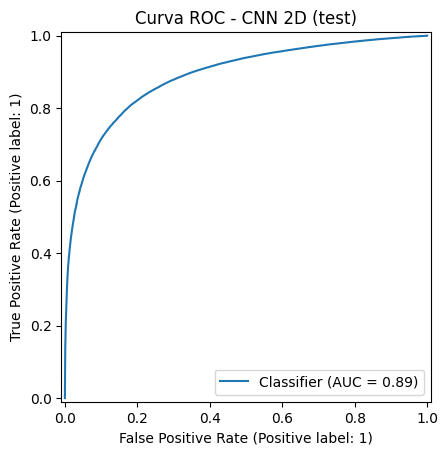

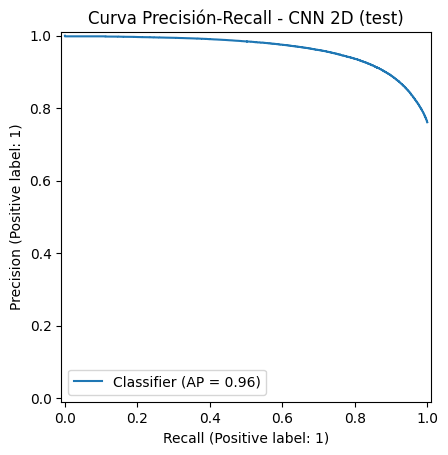

In [110]:
test_loader  = make_loader(X_test2d,  y_test2d,  batch_size=64, shuffle=False)
best_thr = checkpoint_info['best_thr']

y_true_test, y_prob_test = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        prob = torch.softmax(model2d(xb), dim=1)[:, 1].cpu().numpy()

        y_true_test.extend(yb.numpy())
        y_prob_test.extend(prob)

y_true_test = np.array(y_true_test)
y_prob_test = np.array(y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)

roc = roc_auc_score(y_true_test, y_prob_test)
pr  = average_precision_score(y_true_test, y_prob_test)

print("\n--- Reporte de clasificación (TEST) ---")
print(classification_report(y_true_test, y_pred_test, digits=3))
print("ROC-AUC (test):", roc)
print("PR-AUC  (test):", pr)

print("\nMatriz de confusión (TEST):")
print(confusion_matrix(y_true_test, y_pred_test))

# Curvas ROC y PR
RocCurveDisplay.from_predictions(y_true_test, y_prob_test)
plt.title("Curva ROC - CNN 2D (test)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_true_test, y_prob_test)
plt.title("Curva Precisión-Recall - CNN 2D (test)")
plt.show()

### Gráfico Real VS Predicción (Test)

In [98]:
print(
"""
Hay que hacer un gráfico para devolver el entrenamiento a los datos originales y poder comparar si seguimos teniendo pimienta y sal o si realmente logramos mejorar la clasificación
porque la 2D da buenos resultamos pero en una dimensión redundante, supongo que hay que volver al estado inicial para ver si la clasificación lo hace bien?
"""
)


Hay que hacer un gráfico para devolver el entrenamiento a los datos originales y poder comparar si seguimos teniendo pimienta y sal o si realmente logramos mejorar la clasificación
porque la 2D da buenos resultamos pero en una dimensión redundante, supongo que hay que volver al estado inicial para ver si la clasificación lo hace bien?



In [111]:
def build_patch_dataset_with_coords(cube, labels_2d, split_2d, split_value, patch=7):
    H, W, B = cube.shape
    r = patch // 2

    X_list = []
    y_list = []
    coords = []  # <- NUEVO

    for i in range(r, H - r):
        for j in range(r, W - r):

            if split_2d[i, j] != split_value:
                continue
            if np.isnan(labels_2d[i, j]):
                continue

            patch_cube = cube[i-r:i+r+1, j-r:j+r+1, :]
            if np.isnan(patch_cube).any():
                continue

            patch_chw = np.transpose(patch_cube, (2, 0, 1))

            X_list.append(patch_chw)
            y_list.append(labels_2d[i, j])
            coords.append((i, j))  # <- guardamos posición del píxel central

    X_arr = np.stack(X_list)
    y_arr = np.array(y_list, dtype=np.int64)

    return X_arr, y_arr, np.array(coords)

In [112]:
X_train2d, y_train2d, coords_train = build_patch_dataset_with_coords(
    cube_scaled, labels_bin, split_2d, 1, patch=PATCH)

X_val2d, y_val2d, coords_val = build_patch_dataset_with_coords(
    cube_scaled, labels_bin, split_2d, 2, patch=PATCH)

X_test2d, y_test2d, coords_test = build_patch_dataset_with_coords(
    cube_scaled, labels_bin, split_2d, 3, patch=PATCH)


In [128]:
coords_test

array([[ 350, 1148],
       [ 351, 1148],
       [ 351, 1149],
       ...,
       [2987, 1639],
       [2987, 1640],
       [2987, 1641]], shape=(251856, 2))

In [119]:
print(X_train2d.shape, y_train2d.shape,
      X_val2d.shape, y_val2d.shape,
      X_test2d.shape, y_test2d.shape,
      )

(717464, 63, 5, 5) (717464,) (244480, 63, 5, 5) (244480,) (251856, 63, 5, 5) (251856,)


In [127]:
y_train2d.shape[0] + y_val2d.shape[0] + y_test2d.shape[0]

1213800

In [126]:
(split_id == 1).sum().sum(), (split_id == 2).sum().sum(), (split_id == 3).sum().sum()

(np.int64(1038541), np.int64(353211), np.int64(372966))

In [114]:
y_true_test

array([1, 1, 1, ..., 0, 0, 0], shape=(251856,))

In [115]:
y_pred_test

array([1, 1, 1, ..., 1, 1, 1], shape=(251856,))

In [117]:
H, W = labels_bin.shape
pred_map = np.full((H, W), np.nan)

for (i, j), p in zip(coords_test, y_pred_test):
    pred_map[i, j] = p

pred_map.shape

(3660, 3438)

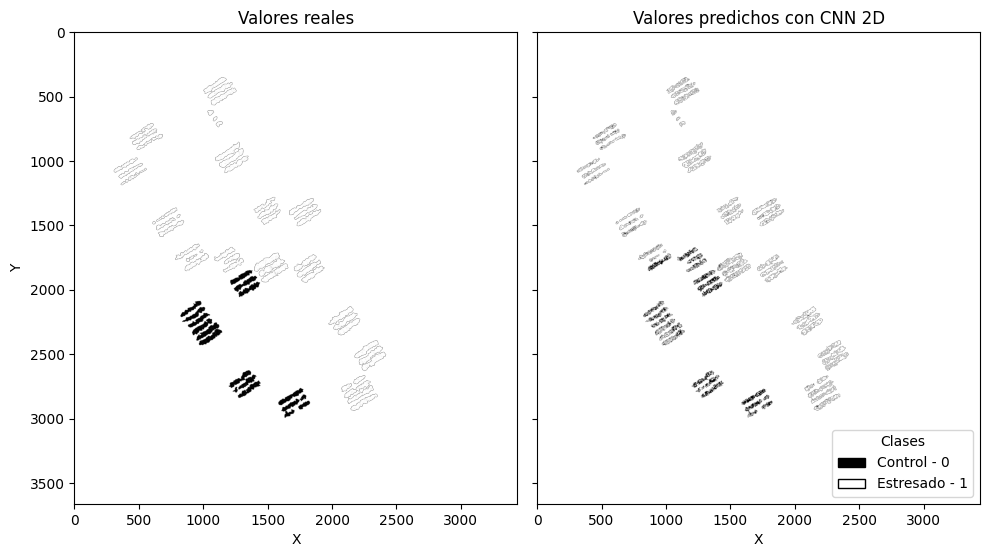

In [131]:
real_test = np.where(split_id == 3, labels_bin, np.nan)
pred_test = np.where(split_id == 3, pred_map, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(10, 8), sharey=True)
ax = ax.flatten()
ax[0].imshow(real_test, cmap="gray", extent=extent, origin="upper")
ax[1].imshow(pred_test, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]

ax[1].legend(handles=legend_elements, title="Clases", loc="lower right")

ax[1].set_title("Valores predichos con CNN 2D")
ax[0].set_title("Valores reales")
ax[0].set_xlabel("X")
ax[1].set_xlabel("X")
ax[0].set_ylabel("Y")
fig.tight_layout()
plt.show()
